# 🌫️ Dhaka Air Quality Analysis (2017–2025)

This notebook performs a comprehensive analysis of Dhaka's air quality using monthly data covering PM2.5, PM10, NO₂, SO₂ and AQI from 2017 to 2025.

**Sections:**
1. Setup & Data Loading
2. Dataset Overview
3. Long-Term AQI & Pollutant Trends
4. Seasonal Patterns
5. Pollutant Profiles & Relationships
6. COVID-19 Impact Analysis
7. Rainfall vs Pollution
8. Socioeconomic Context
9. Year-over-Year Heatmap
10. Rolling Statistics & Trend Decomposition
11. Correlation Analysis
12. Key Insights Summary

## 1. Setup & Data Loading

In [1]:
import os, pathlib

# ── Automatically set working directory to the DHAKA-AQI project root ──
# Works whether you run the notebook from the notebooks/ subfolder or the root
notebook_dir = pathlib.Path().resolve()

# Walk up until we find the data/processed folder
search = notebook_dir
for _ in range(4):  # look up to 4 levels up
    candidate = search / 'data' / 'processed' / 'final_dhaka_aqi_dataset_clean.csv'
    if candidate.exists():
        os.chdir(search)
        break
    search = search.parent

DATA_PATH = pathlib.Path('data/processed/final_dhaka_aqi_dataset_clean.csv')
assert DATA_PATH.exists(), (
    f'CSV not found at {DATA_PATH.resolve()}.\n'
    f'Make sure final_dhaka_aqi_dataset_clean.csv is in data/processed/ '
    f'relative to the DHAKA-AQI project root.'
)
print(f'✓ Working directory: {pathlib.Path().resolve()}')
print(f'✓ Dataset found at:  {DATA_PATH.resolve()}')

✓ Working directory: /home/abhowmik/Desktop/dhaka-aqi
✓ Dataset found at:  /home/abhowmik/Desktop/dhaka-aqi/data/processed/final_dhaka_aqi_dataset_clean.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#e0e0e0',
    'axes.titlecolor':  '#ffffff',
    'axes.grid':        True,
    'grid.color':       '#2a2d3d',
    'grid.linewidth':   0.6,
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'text.color':       '#e0e0e0',
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#3a3d4d',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

# Palette
PAL = {
    'pm25':  '#FF6B6B',
    'pm10':  '#FFA94D',
    'no2':   '#74C0FC',
    'so2':   '#A9E34B',
    'aqi':   '#DA77F2',
    'rain':  '#4FC3F7',
}
SEASON_PAL = {
    'Winter':       '#74C0FC',
    'Pre-monsoon':  '#FFA94D',
    'Monsoon':      '#A9E34B',
    'Post-monsoon': '#DA77F2',
}

print('Libraries loaded ✓')

Libraries loaded ✓


In [3]:
# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH, parse_dates=['month_start'])
df = df.sort_values('month_start').reset_index(drop=True)

# Ordered season category
season_order = ['Winter', 'Pre-monsoon', 'Monsoon', 'Post-monsoon']
df['season'] = pd.Categorical(df['season'], categories=season_order, ordered=True)

# WHO guideline reference levels (annual mean, µg/m³)
WHO = {'pm25': 15, 'pm10': 45, 'no2': 10, 'so2': 40}

print(f'Rows: {len(df)} | Date range: {df.month_start.min().date()} → {df.month_start.max().date()}')
df.head(3)

Rows: 108 | Date range: 2017-01-01 → 2025-12-01


,month_start,year,month,pm25_mean,pm25_median,pm25_min,pm25_max,pm10_mean,pm10_median,pm10_min,...,aqi_median,aqi_min,aqi_max,population_total,urban_population,urban_share_pct,hdi,poverty_rate_pct,norm_rain,season
0,2017-01-01,2017,1,176.36,177.37,73.01,250.00,512.4,508.8,191.1,...,226.90,159.23,299.60,162149117,59054708,0.3642,0.622,24.3,0.000000,Winter
1,2017-02-01,2017,2,175.32,176.26,92.84,250.00,500.2,496.7,186.6,...,225.78,169.67,299.60,162149117,59054708,0.3642,0.622,24.3,0.003480,Winter
2,2017-03-01,2017,3,117.30,117.16,41.21,186.93,378.2,365.7,108.6,...,182.49,114.34,236.46,162149117,59054708,0.3642,0.622,24.3,0.171379,Pre-monsoon


## 2. Dataset Overview

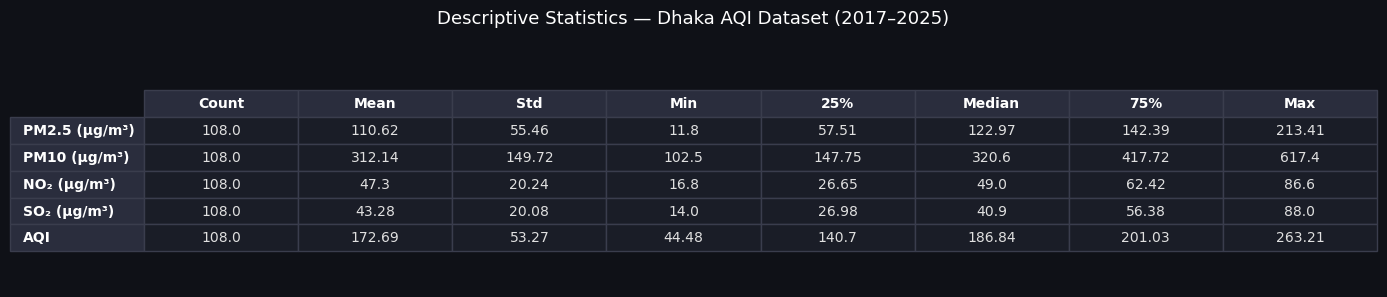

In [4]:
pollutants = ['pm25_mean', 'pm10_mean', 'no2_mean', 'so2_mean', 'aqi_mean']
summary = df[pollutants].describe().T
summary.columns = ['Count', 'Mean', 'Std', 'Min', '25%', 'Median', '75%', 'Max']
summary = summary.round(2)
summary.index = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO₂ (µg/m³)', 'SO₂ (µg/m³)', 'AQI']

fig, ax = plt.subplots(figsize=(14, 3), facecolor='#0f1117')
ax.axis('off')
tbl = ax.table(
    cellText=summary.values,
    rowLabels=summary.index,
    colLabels=summary.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#3a3d4d')
    if r == 0 or c == -1:
        cell.set_facecolor('#2a2d3d')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#1a1d27')
        cell.set_text_props(color='#e0e0e0')
fig.suptitle('Descriptive Statistics — Dhaka AQI Dataset (2017–2025)', color='white', fontsize=13, y=0.98)
plt.tight_layout()
plt.show()

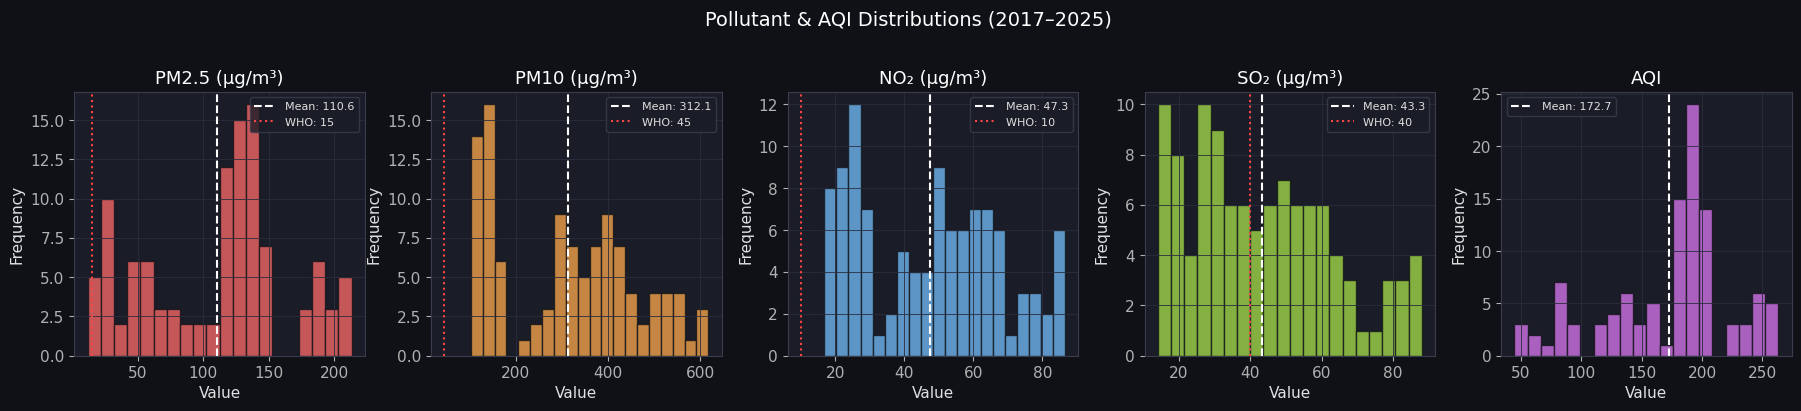

In [5]:
# Distribution of each pollutant
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Pollutant & AQI Distributions (2017–2025)', fontsize=14, color='white', y=1.02)

items = [
    ('pm25_mean', 'PM2.5', PAL['pm25'], WHO['pm25']),
    ('pm10_mean', 'PM10',  PAL['pm10'], WHO['pm10']),
    ('no2_mean',  'NO₂',   PAL['no2'],  WHO['no2']),
    ('so2_mean',  'SO₂',   PAL['so2'],  WHO['so2']),
    ('aqi_mean',  'AQI',   PAL['aqi'],  None),
]

for ax, (col, label, color, who) in zip(axes, items):
    data = df[col].dropna()
    ax.hist(data, bins=20, color=color, alpha=0.75, edgecolor='#0f1117')
    ax.axvline(data.mean(), color='white', lw=1.5, linestyle='--', label=f'Mean: {data.mean():.1f}')
    if who:
        ax.axvline(who, color='#FF4444', lw=1.5, linestyle=':', label=f'WHO: {who}')
    ax.set_title(f'{label} (µg/m³)' if label != 'AQI' else 'AQI', color='white')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Long-Term AQI & Pollutant Trends

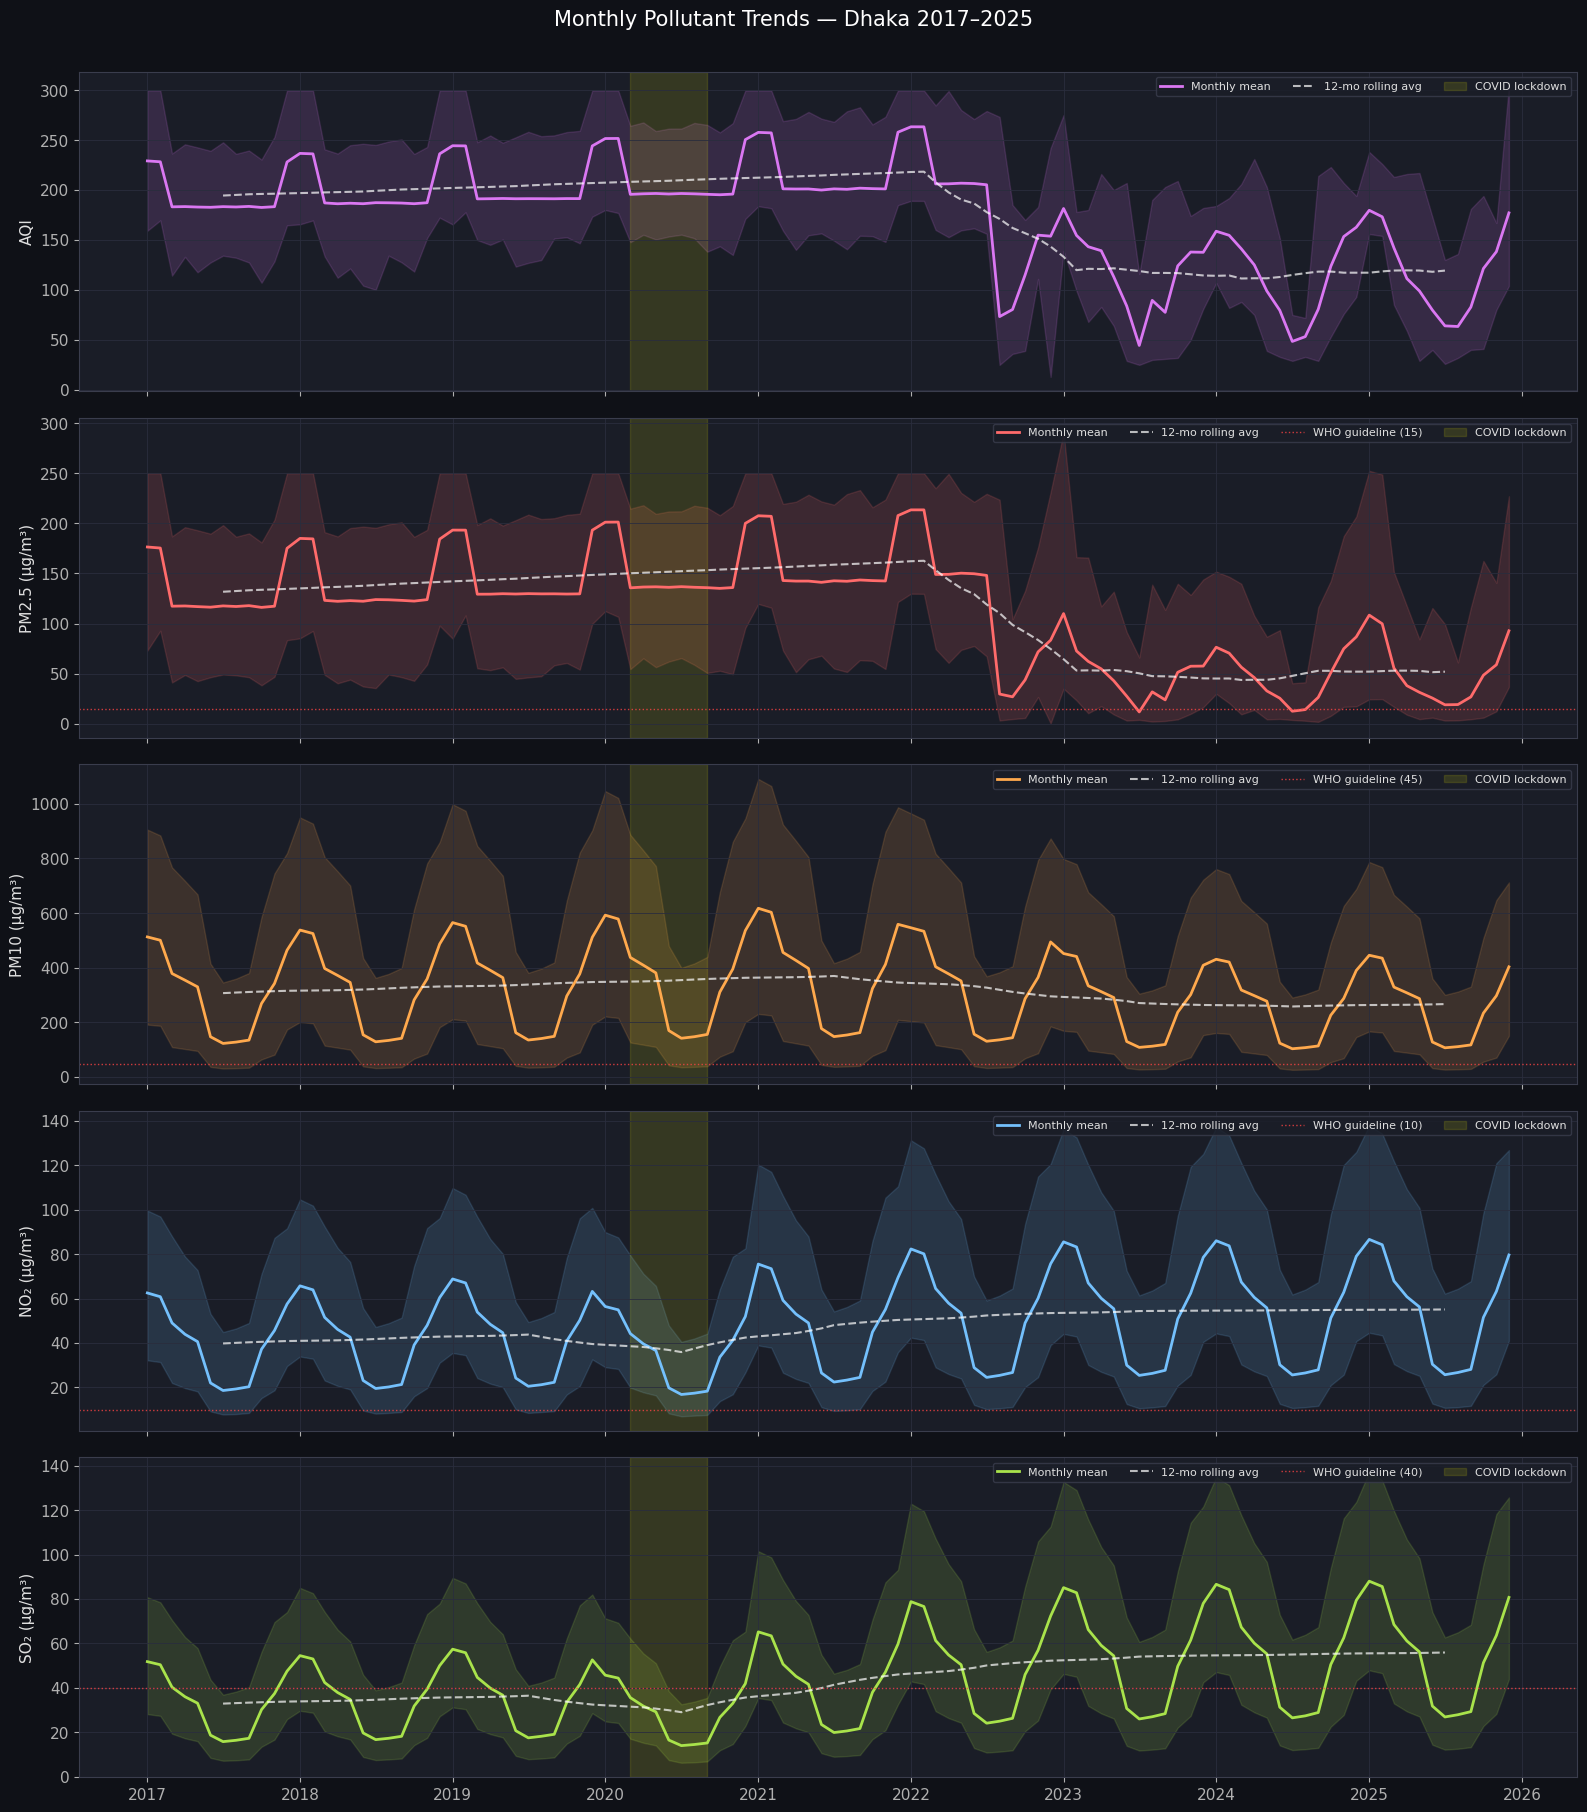

In [6]:
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)
fig.suptitle('Monthly Pollutant Trends — Dhaka 2017–2025', fontsize=15, color='white', y=1.005)

series = [
    ('aqi_mean',  'aqi_min',  'aqi_max',  'AQI',           PAL['aqi'],  None),
    ('pm25_mean', 'pm25_min', 'pm25_max', 'PM2.5 (µg/m³)', PAL['pm25'], WHO['pm25']),
    ('pm10_mean', 'pm10_min', 'pm10_max', 'PM10 (µg/m³)',  PAL['pm10'], WHO['pm10']),
    ('no2_mean',  'no2_min',  'no2_max',  'NO₂ (µg/m³)',   PAL['no2'],  WHO['no2']),
    ('so2_mean',  'so2_min',  'so2_max',  'SO₂ (µg/m³)',   PAL['so2'],  WHO['so2']),
]

for ax, (mean_col, min_col, max_col, ylabel, color, who) in zip(axes, series):
    x = df['month_start']
    ax.fill_between(x, df[min_col], df[max_col], alpha=0.15, color=color)
    ax.plot(x, df[mean_col], color=color, lw=2, label='Monthly mean')
    # 12-month rolling mean
    roll = df[mean_col].rolling(12, center=True).mean()
    ax.plot(x, roll, color='white', lw=1.5, linestyle='--', alpha=0.7, label='12-mo rolling avg')
    if who:
        ax.axhline(who, color='#FF4444', lw=1, linestyle=':', alpha=0.8, label=f'WHO guideline ({who})')
    # Shade COVID period
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-09-01'),
               alpha=0.12, color='yellow', label='COVID lockdown')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, loc='upper right', ncol=4)

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

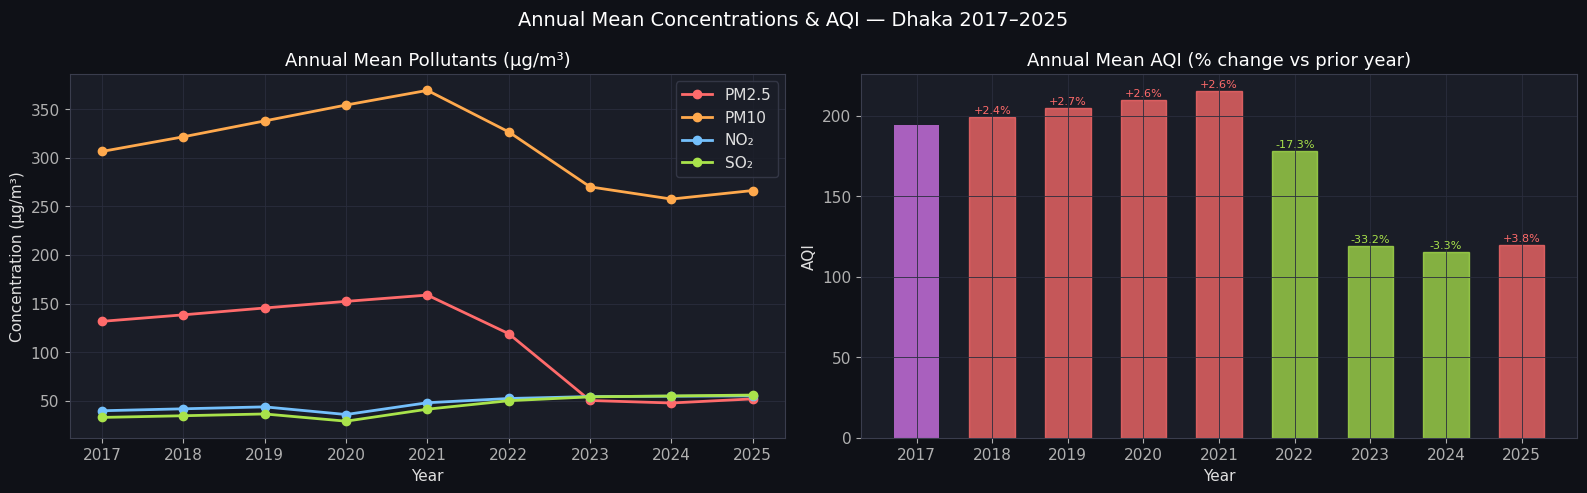

In [7]:
# Annual means with trend lines
annual = df.groupby('year')[['pm25_mean','pm10_mean','no2_mean','so2_mean','aqi_mean']].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Annual Mean Concentrations & AQI — Dhaka 2017–2025', fontsize=14, color='white')

# Left: Pollutants
ax = axes[0]
for col, label, color in [
    ('pm25_mean', 'PM2.5', PAL['pm25']),
    ('pm10_mean', 'PM10',  PAL['pm10']),
    ('no2_mean',  'NO₂',   PAL['no2']),
    ('so2_mean',  'SO₂',   PAL['so2']),
]:
    ax.plot(annual.index, annual[col], marker='o', color=color, lw=2, label=label)
ax.set_title('Annual Mean Pollutants (µg/m³)')
ax.set_xlabel('Year')
ax.set_ylabel('Concentration (µg/m³)')
ax.legend()
ax.set_xticks(annual.index)

# Right: AQI with YoY % change
ax2 = axes[1]
bars = ax2.bar(annual.index, annual['aqi_mean'], color=PAL['aqi'], alpha=0.75, width=0.6)
# Color bars by improvement/worsening vs prev year
yoy = annual['aqi_mean'].pct_change() * 100
for i, (bar, pct) in enumerate(zip(bars, yoy)):
    if pd.notna(pct):
        color = '#FF6B6B' if pct > 0 else '#A9E34B'
        bar.set_color(color)
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{pct:+.1f}%', ha='center', va='bottom', fontsize=8, color=color)
ax2.set_title('Annual Mean AQI (% change vs prior year)')
ax2.set_xlabel('Year')
ax2.set_ylabel('AQI')
ax2.set_xticks(annual.index)

plt.tight_layout()
plt.show()

## 4. Seasonal Patterns

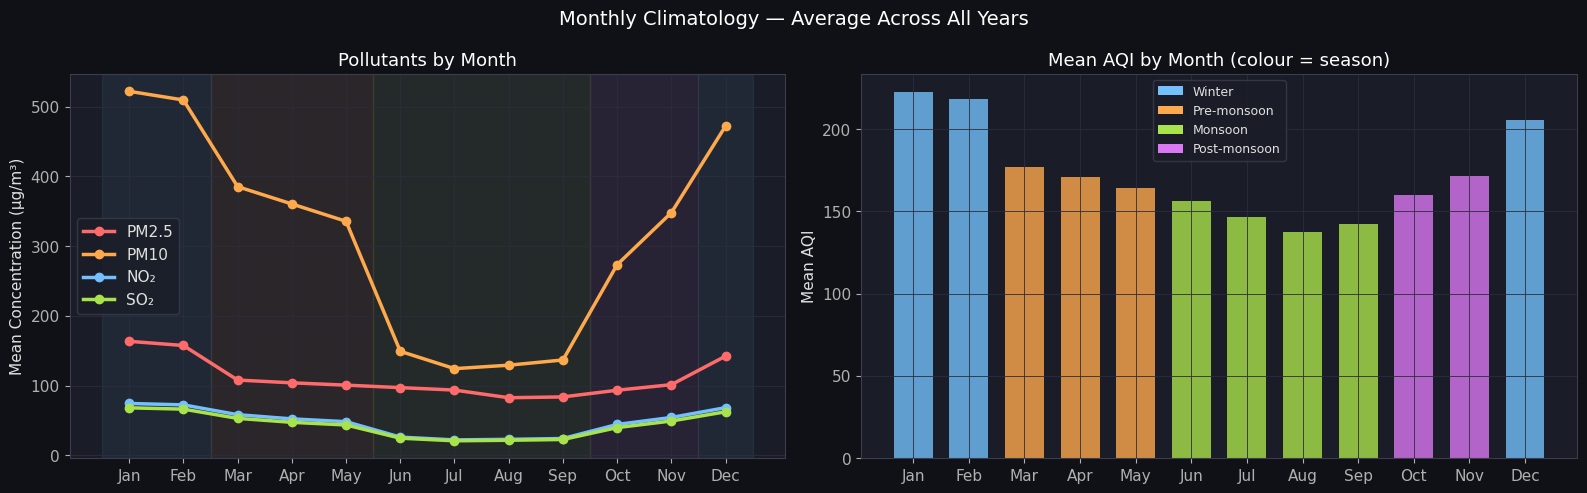

In [8]:
# Monthly climatology — average of each month across all years
monthly_clim = df.groupby('month')[['pm25_mean','pm10_mean','no2_mean','so2_mean','aqi_mean']].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Monthly Climatology — Average Across All Years', fontsize=14, color='white')

# Left: Pollutants
ax = axes[0]
for col, label, color in [
    ('pm25_mean', 'PM2.5', PAL['pm25']),
    ('pm10_mean', 'PM10',  PAL['pm10']),
    ('no2_mean',  'NO₂',   PAL['no2']),
    ('so2_mean',  'SO₂',   PAL['so2']),
]:
    ax.plot(monthly_clim.index, monthly_clim[col], marker='o', color=color, lw=2.5, label=label)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel('Mean Concentration (µg/m³)')
ax.set_title('Pollutants by Month')
ax.legend()
# Add season bands
for start, end, label, c in [
    (11.5, 12.5, '', '#74C0FC'), (0.5, 2.5, 'Winter', '#74C0FC'),
    (2.5, 5.5, 'Pre-monsoon', '#FFA94D'),
    (5.5, 9.5, 'Monsoon', '#A9E34B'),
    (9.5, 11.5, 'Post-\nmonsoon', '#DA77F2')
]:
    ax.axvspan(start, end, alpha=0.07, color=c)

# Right: AQI by month
ax2 = axes[1]
colors_bar = [SEASON_PAL[s] for s in
    ['Winter','Winter','Pre-monsoon','Pre-monsoon','Pre-monsoon',
     'Monsoon','Monsoon','Monsoon','Monsoon','Post-monsoon','Post-monsoon','Winter']]
bars = ax2.bar(monthly_clim.index, monthly_clim['aqi_mean'], color=colors_bar, alpha=0.8, width=0.7)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(month_labels)
ax2.set_ylabel('Mean AQI')
ax2.set_title('Mean AQI by Month (colour = season)')
# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=s) for s, c in SEASON_PAL.items()]
ax2.legend(handles=legend_els, fontsize=9)

plt.tight_layout()
plt.show()

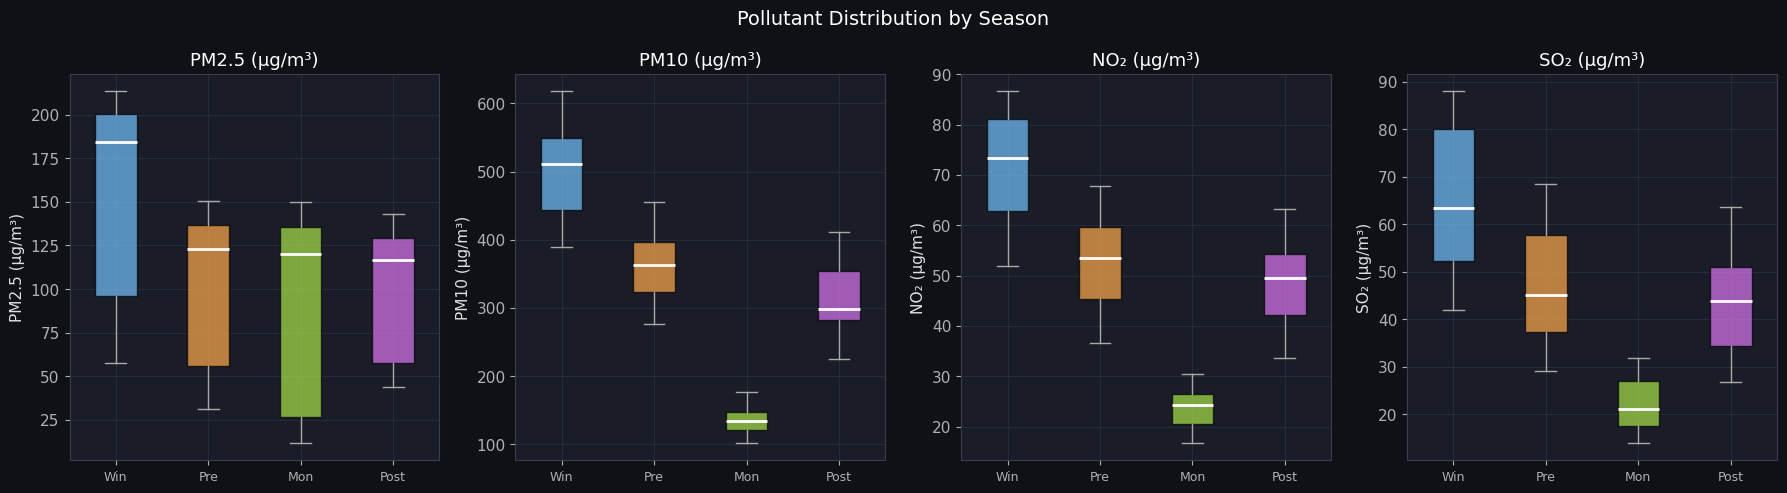

In [9]:
# Box plots by season
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Pollutant Distribution by Season', fontsize=14, color='white')

for ax, (col, label, color) in zip(axes, [
    ('pm25_mean', 'PM2.5 (µg/m³)', PAL['pm25']),
    ('pm10_mean', 'PM10 (µg/m³)',  PAL['pm10']),
    ('no2_mean',  'NO₂ (µg/m³)',   PAL['no2']),
    ('so2_mean',  'SO₂ (µg/m³)',   PAL['so2']),
]):
    season_data = [df[df['season'] == s][col].values for s in season_order]
    bp = ax.boxplot(season_data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', lw=2),
                    whiskerprops=dict(color='#aaa'), capprops=dict(color='#aaa'),
                    flierprops=dict(marker='o', markerfacecolor='#aaa', markersize=4))
    for patch, s in zip(bp['boxes'], season_order):
        patch.set_facecolor(SEASON_PAL[s])
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Win', 'Pre', 'Mon', 'Post'], fontsize=9)
    ax.set_title(label)
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

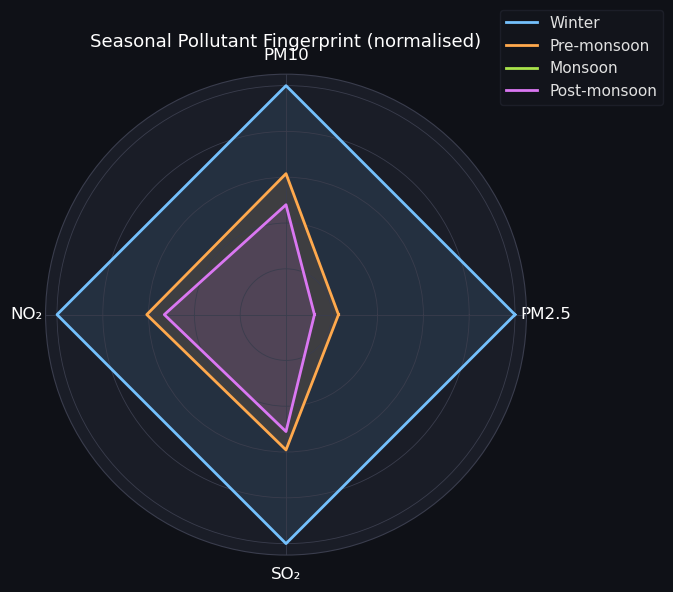

In [10]:
# Radar chart — seasonal pollutant fingerprint
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

season_means = df.groupby('season')[['pm25_mean','pm10_mean','no2_mean','so2_mean']].mean()
# Normalise each pollutant 0-1
norm = (season_means - season_means.min()) / (season_means.max() - season_means.min())

categories = ['PM2.5', 'PM10', 'NO₂', 'SO₂']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True), facecolor='#0f1117')
ax.set_facecolor('#1a1d27')

for season in season_order:
    values = norm.loc[season].tolist()
    values += values[:1]
    ax.plot(angles, values, lw=2, color=SEASON_PAL[season], label=season)
    ax.fill(angles, values, alpha=0.12, color=SEASON_PAL[season])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, color='white', fontsize=12)
ax.set_yticklabels([])
ax.spines['polar'].set_color('#3a3d4d')
ax.grid(color='#3a3d4d')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), framealpha=0.3)
ax.set_title('Seasonal Pollutant Fingerprint (normalised)', color='white', pad=20, fontsize=13)
plt.tight_layout()
plt.show()

## 5. Pollutant Profiles & Relationships

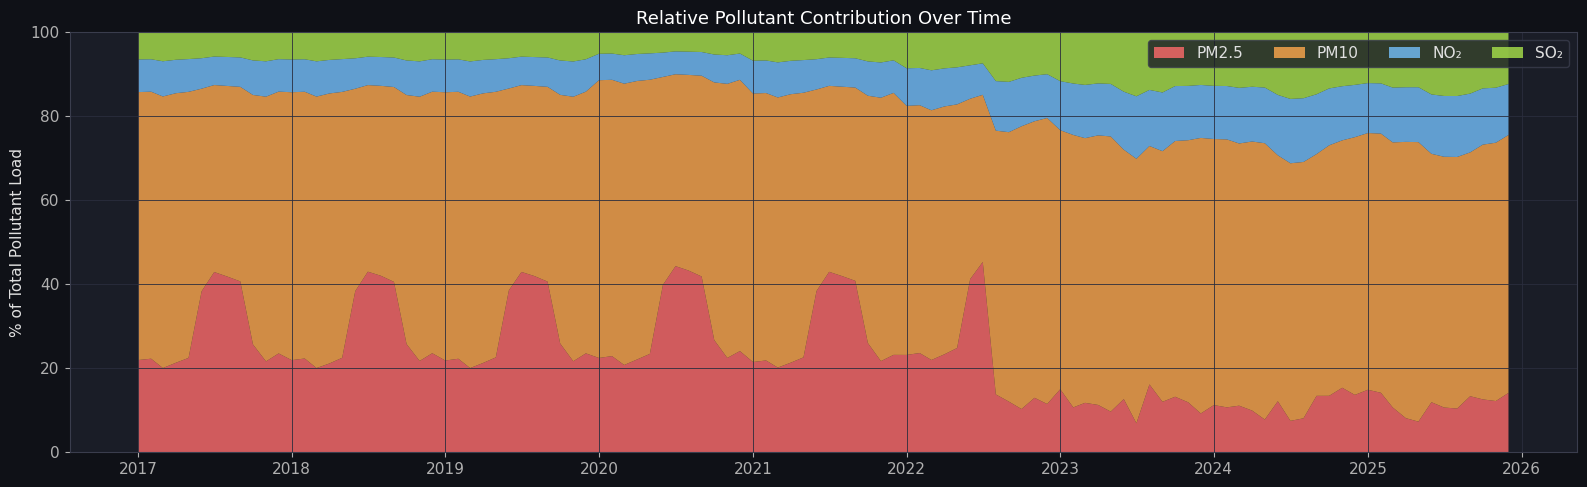

In [11]:
# Stacked area — relative pollutant contribution over time
fig, ax = plt.subplots(figsize=(16, 5))

pollutant_cols = ['pm25_mean', 'pm10_mean', 'no2_mean', 'so2_mean']
labels = ['PM2.5', 'PM10', 'NO₂', 'SO₂']
colors = [PAL['pm25'], PAL['pm10'], PAL['no2'], PAL['so2']]

total = df[pollutant_cols].sum(axis=1)
pct_df = df[pollutant_cols].div(total, axis=0) * 100

ax.stackplot(df['month_start'], [pct_df[c] for c in pollutant_cols],
             labels=labels, colors=colors, alpha=0.8)
ax.set_ylabel('% of Total Pollutant Load')
ax.set_title('Relative Pollutant Contribution Over Time')
ax.legend(loc='upper right', ncol=4)
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

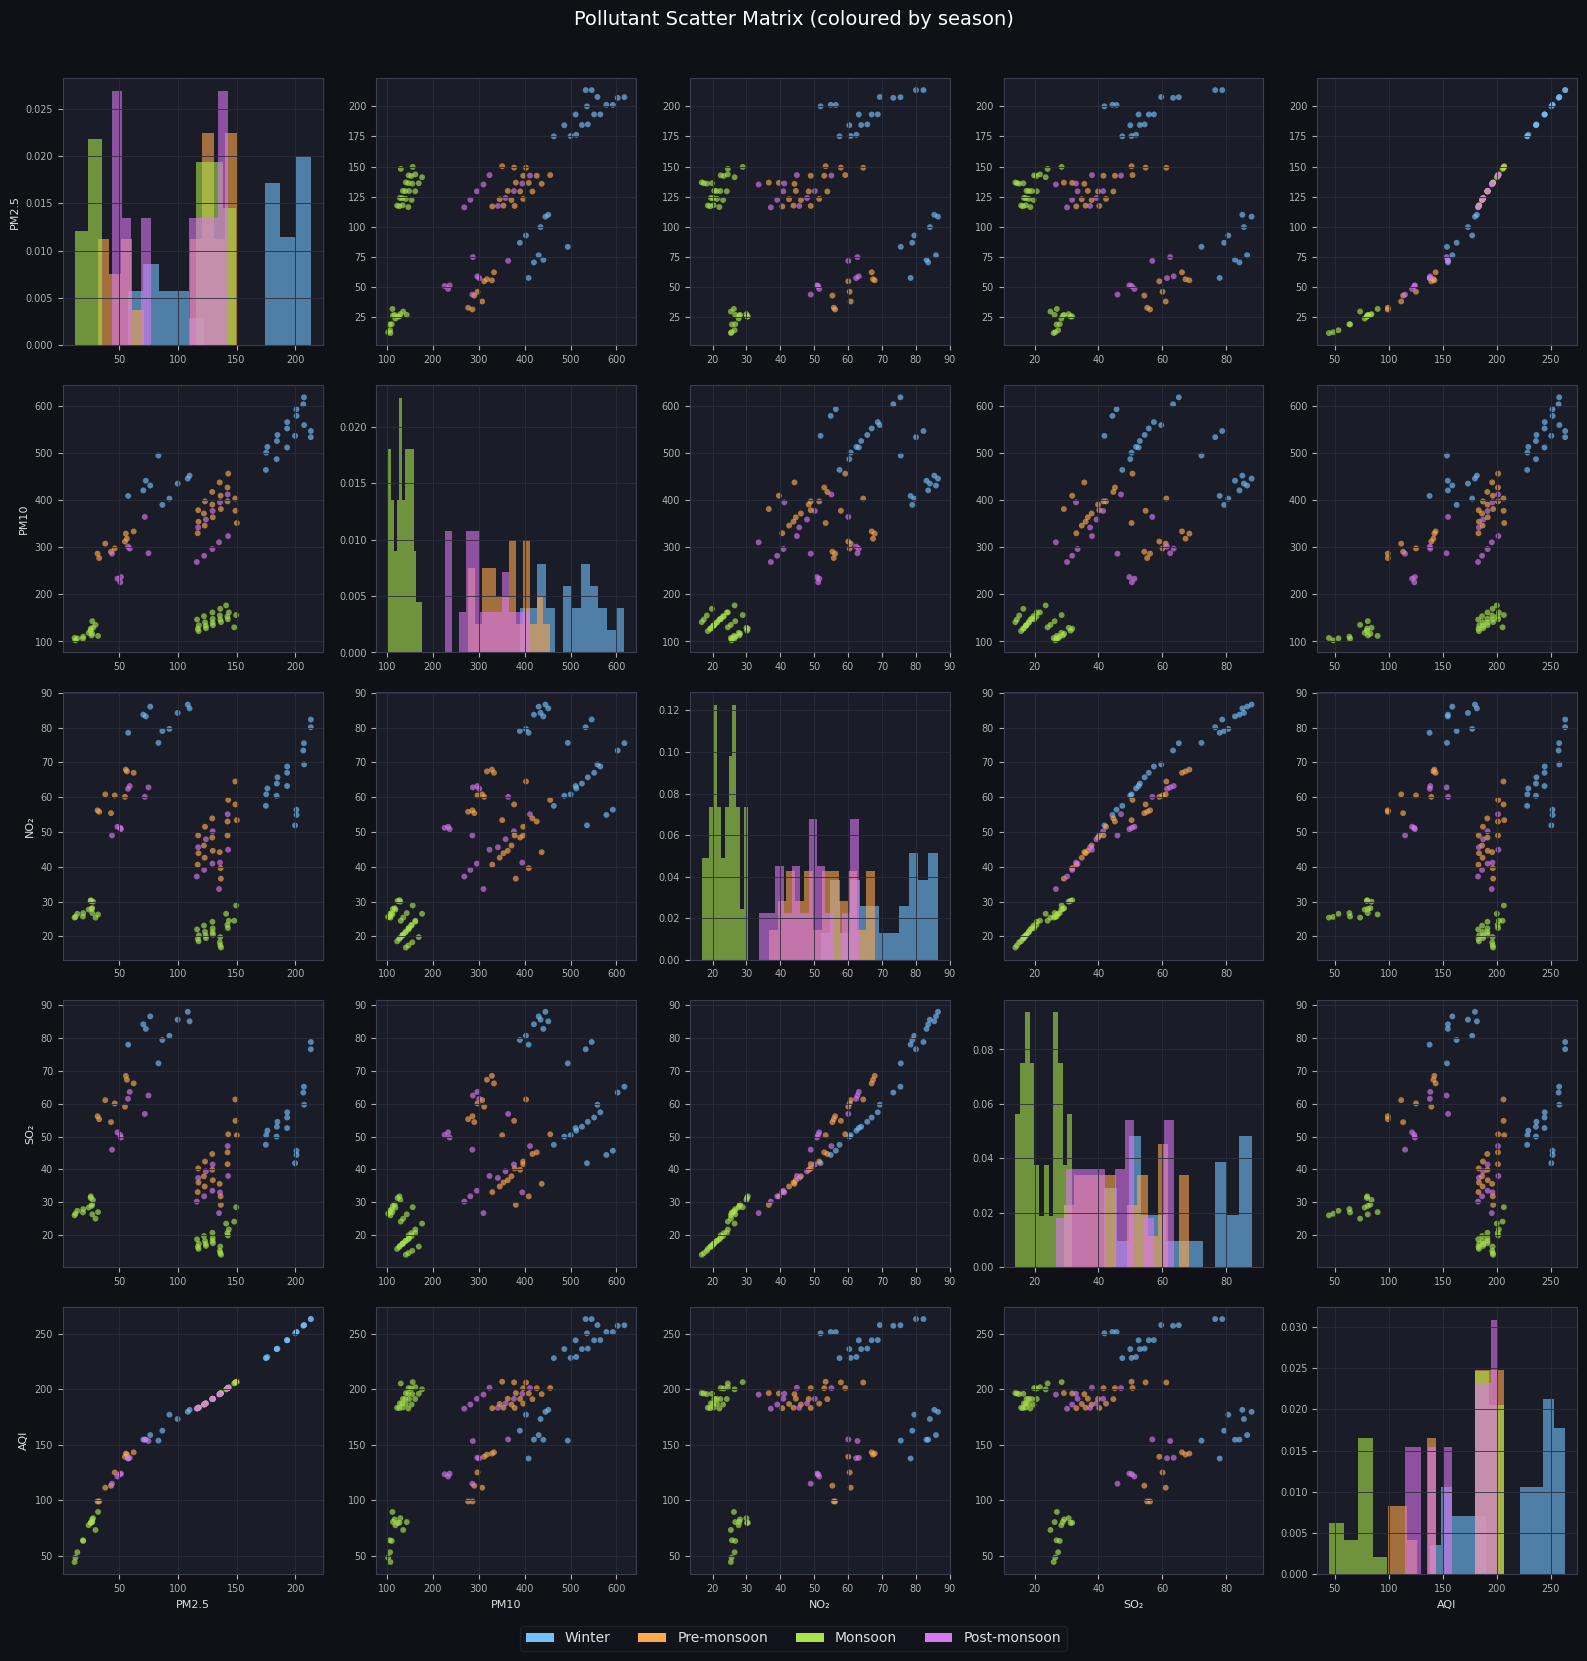

In [12]:
# Scatter matrix for mean pollutants, coloured by season
plot_cols = ['pm25_mean', 'pm10_mean', 'no2_mean', 'so2_mean', 'aqi_mean']
plot_labels = {'pm25_mean':'PM2.5','pm10_mean':'PM10','no2_mean':'NO₂','so2_mean':'SO₂','aqi_mean':'AQI'}

fig, axes = plt.subplots(5, 5, figsize=(16, 16))
fig.suptitle('Pollutant Scatter Matrix (coloured by season)', fontsize=14, color='white', y=1.01)

for i, col_i in enumerate(plot_cols):
    for j, col_j in enumerate(plot_cols):
        ax = axes[i][j]
        if i == j:
            for s in season_order:
                subset = df[df['season'] == s][col_i]
                ax.hist(subset, bins=12, alpha=0.6, color=SEASON_PAL[s], density=True)
            ax.set_facecolor('#1a1d27')
        else:
            for s in season_order:
                sub = df[df['season'] == s]
                ax.scatter(sub[col_j], sub[col_i], s=18, alpha=0.65,
                           color=SEASON_PAL[s], edgecolors='none')
            ax.set_facecolor('#1a1d27')
        if i == 4:
            ax.set_xlabel(plot_labels[col_j], fontsize=8)
        if j == 0:
            ax.set_ylabel(plot_labels[col_i], fontsize=8)
        ax.tick_params(labelsize=7)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=s) for s, c in SEASON_PAL.items()]
fig.legend(handles=legend_els, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), framealpha=0.3)
plt.tight_layout()
plt.show()

## 6. COVID-19 Impact Analysis

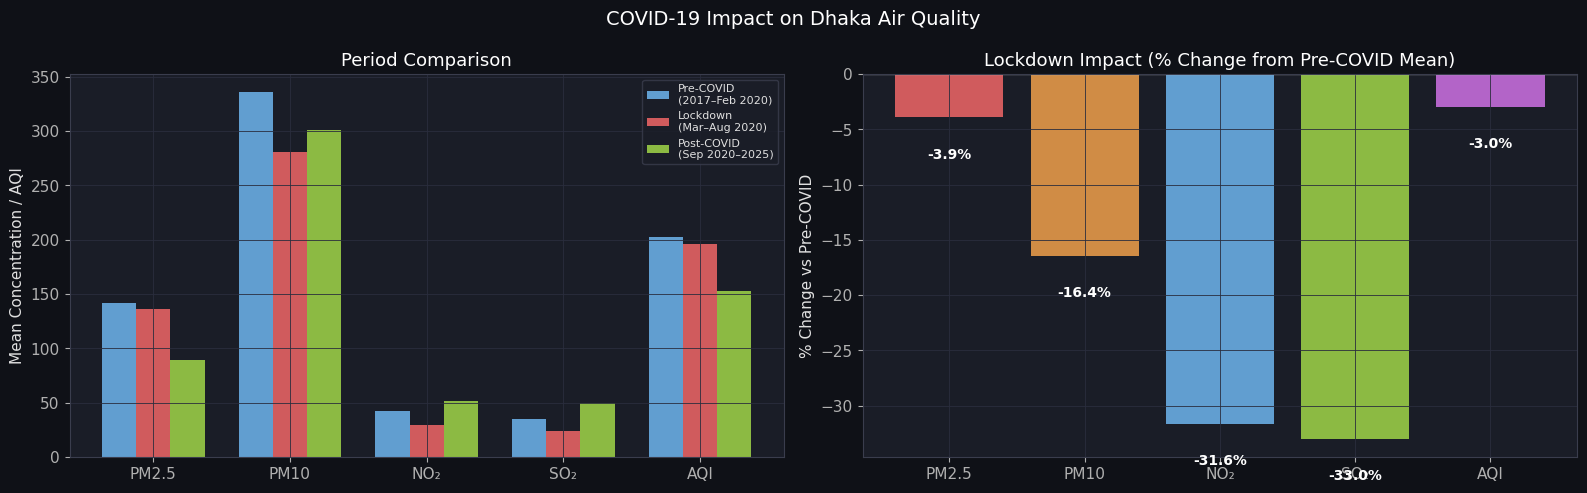

In [13]:
# Define periods
pre_covid   = df[df['month_start'] < '2020-03-01']
lockdown    = df[(df['month_start'] >= '2020-03-01') & (df['month_start'] <= '2020-08-31')]
post_covid  = df[df['month_start'] > '2020-08-31']

# Mean comparison
period_means = pd.DataFrame({
    'Pre-COVID\n(2017–Feb 2020)':   pre_covid[['pm25_mean','pm10_mean','no2_mean','so2_mean','aqi_mean']].mean(),
    'Lockdown\n(Mar–Aug 2020)':     lockdown[['pm25_mean','pm10_mean','no2_mean','so2_mean','aqi_mean']].mean(),
    'Post-COVID\n(Sep 2020–2025)':  post_covid[['pm25_mean','pm10_mean','no2_mean','so2_mean','aqi_mean']].mean(),
}).T
period_means.columns = ['PM2.5', 'PM10', 'NO₂', 'SO₂', 'AQI']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('COVID-19 Impact on Dhaka Air Quality', fontsize=14, color='white')

# Grouped bar chart
ax = axes[0]
x = np.arange(len(period_means.columns))
width = 0.25
period_colors = ['#74C0FC', '#FF6B6B', '#A9E34B']
for i, (period, row) in enumerate(period_means.iterrows()):
    ax.bar(x + i*width, row.values, width, label=period, color=period_colors[i], alpha=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(period_means.columns)
ax.set_ylabel('Mean Concentration / AQI')
ax.set_title('Period Comparison')
ax.legend(fontsize=8)

# % Change from pre-COVID to lockdown
ax2 = axes[1]
pct_change = ((period_means.loc['Lockdown\n(Mar–Aug 2020)'] - period_means.loc['Pre-COVID\n(2017–Feb 2020)'])
              / period_means.loc['Pre-COVID\n(2017–Feb 2020)']) * 100
bar_colors = [PAL['pm25'], PAL['pm10'], PAL['no2'], PAL['so2'], PAL['aqi']]
bars = ax2.bar(pct_change.index, pct_change.values, color=bar_colors, alpha=0.8)
for bar, val in zip(bars, pct_change.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + (1 if val >= 0 else -4),
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, color='white', fontweight='bold')
ax2.axhline(0, color='white', lw=1, alpha=0.5)
ax2.set_ylabel('% Change vs Pre-COVID')
ax2.set_title('Lockdown Impact (% Change from Pre-COVID Mean)')

plt.tight_layout()
plt.show()

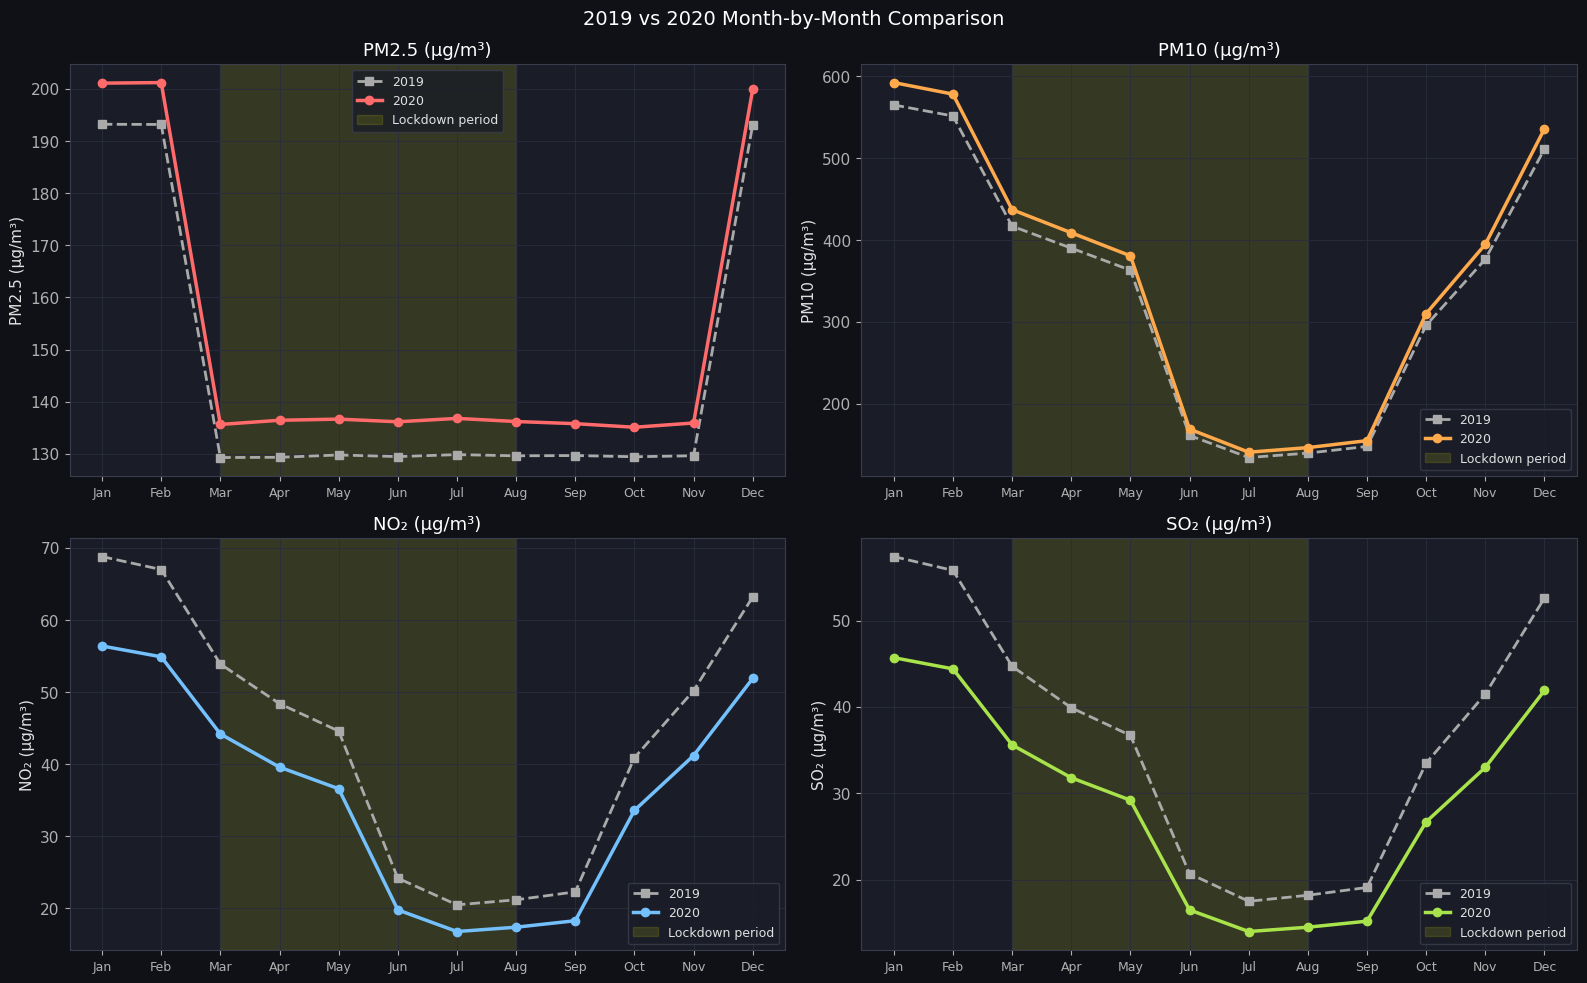

In [14]:
# Year 2019 vs 2020 month-by-month comparison
y2019 = df[df['year'] == 2019].set_index('month')
y2020 = df[df['year'] == 2020].set_index('month')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('2019 vs 2020 Month-by-Month Comparison', fontsize=14, color='white')

for ax, (col, label, color) in zip(axes.flat, [
    ('pm25_mean', 'PM2.5 (µg/m³)', PAL['pm25']),
    ('pm10_mean', 'PM10 (µg/m³)',  PAL['pm10']),
    ('no2_mean',  'NO₂ (µg/m³)',   PAL['no2']),
    ('so2_mean',  'SO₂ (µg/m³)',   PAL['so2']),
]):
    ax.plot(y2019.index, y2019[col], marker='s', color='#aaa', lw=2, label='2019', linestyle='--')
    ax.plot(y2020.index, y2020[col], marker='o', color=color, lw=2.5, label='2020')
    # Shade lockdown months
    ax.axvspan(3, 8, alpha=0.12, color='yellow', label='Lockdown period')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=9)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Rainfall vs Pollution

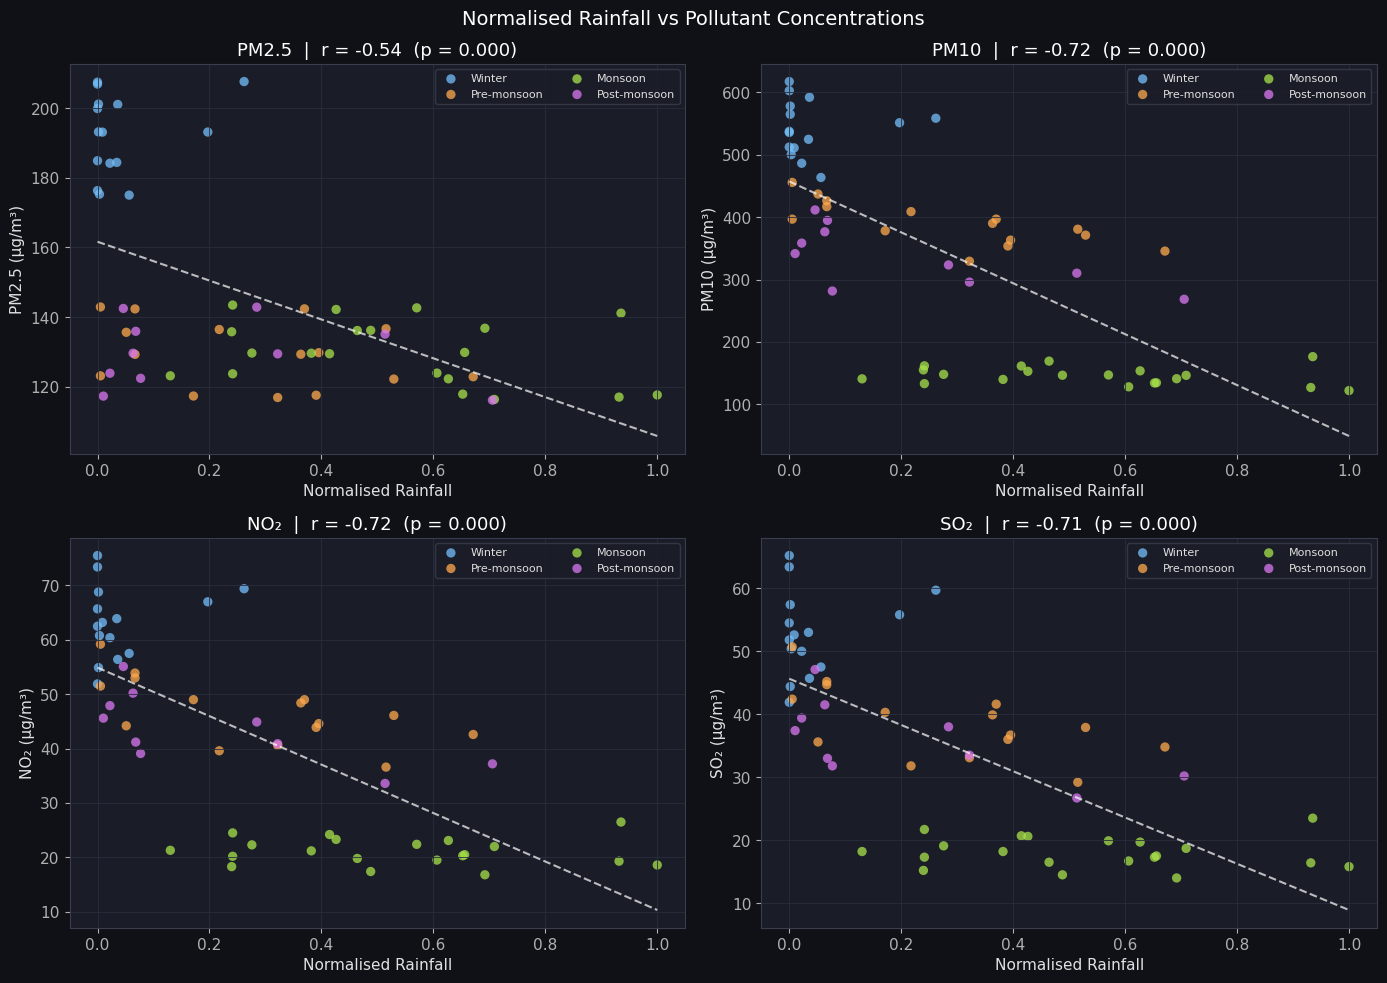

In [15]:
rain_df = df.dropna(subset=['norm_rain'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Normalised Rainfall vs Pollutant Concentrations', fontsize=14, color='white')

for ax, (col, label, color) in zip(axes.flat, [
    ('pm25_mean', 'PM2.5', PAL['pm25']),
    ('pm10_mean', 'PM10',  PAL['pm10']),
    ('no2_mean',  'NO₂',   PAL['no2']),
    ('so2_mean',  'SO₂',   PAL['so2']),
]):
    for s in season_order:
        sub = rain_df[rain_df['season'] == s]
        ax.scatter(sub['norm_rain'], sub[col], color=SEASON_PAL[s], s=45,
                   alpha=0.75, edgecolors='none', label=s)
    # Regression line
    slope, intercept, r, p, _ = stats.linregress(rain_df['norm_rain'], rain_df[col])
    x_line = np.linspace(rain_df['norm_rain'].min(), rain_df['norm_rain'].max(), 100)
    ax.plot(x_line, slope*x_line + intercept, color='white', lw=1.5, linestyle='--', alpha=0.7)
    ax.set_xlabel('Normalised Rainfall')
    ax.set_ylabel(f'{label} (µg/m³)')
    ax.set_title(f'{label}  |  r = {r:.2f}  (p = {p:.3f})')
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

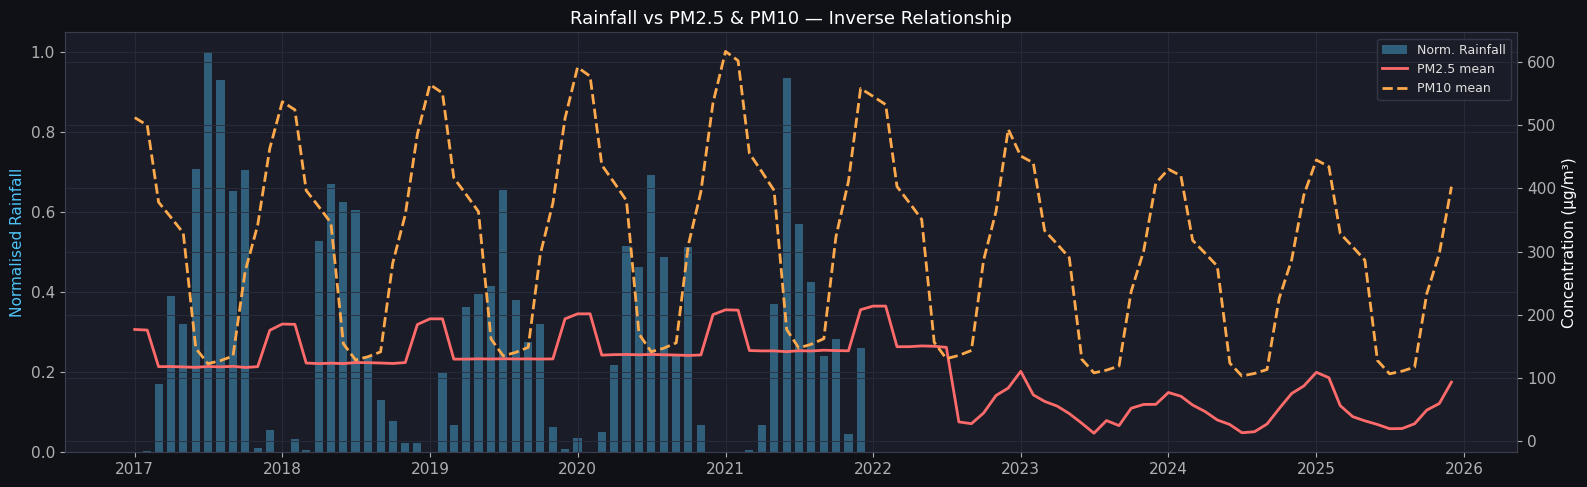

In [16]:
# Dual-axis: rainfall and PM2.5 time series
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.bar(rain_df['month_start'], rain_df['norm_rain'], color=PAL['rain'], alpha=0.4, width=20, label='Norm. Rainfall')
ax2.plot(df['month_start'], df['pm25_mean'], color=PAL['pm25'], lw=2, label='PM2.5 mean')
ax2.plot(df['month_start'], df['pm10_mean'], color=PAL['pm10'], lw=2, label='PM10 mean', linestyle='--')

ax1.set_ylabel('Normalised Rainfall', color=PAL['rain'])
ax2.set_ylabel('Concentration (µg/m³)', color='white')
ax1.set_title('Rainfall vs PM2.5 & PM10 — Inverse Relationship')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=9)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## 8. Socioeconomic Context

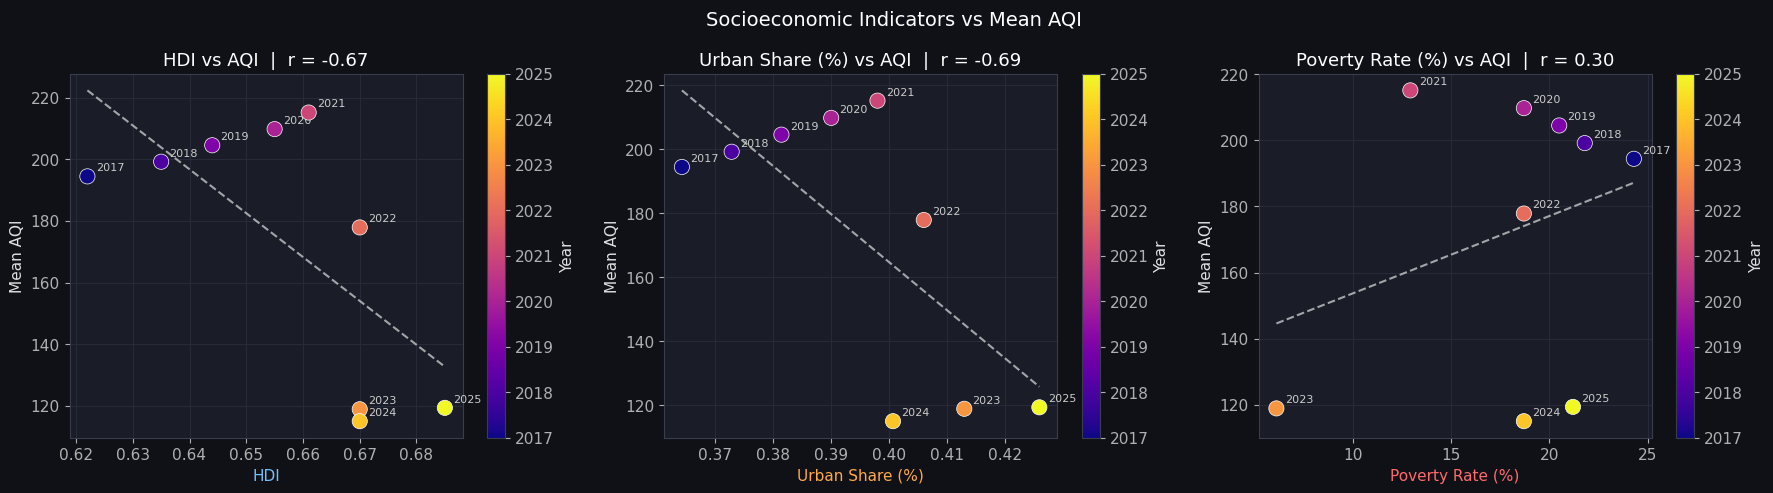

In [17]:
# Annual socioeconomic trends alongside AQI
socio = df.groupby('year').agg(
    aqi_mean=('aqi_mean','mean'),
    hdi=('hdi','first'),
    urban_share=('urban_share_pct','first'),
    poverty_rate=('poverty_rate_pct','first')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Socioeconomic Indicators vs Mean AQI', fontsize=14, color='white')

for ax, (xcol, xlabel, xcolor) in zip(axes, [
    ('hdi',         'HDI',                '#74C0FC'),
    ('urban_share', 'Urban Share (%)',     '#FFA94D'),
    ('poverty_rate','Poverty Rate (%)',    '#FF6B6B'),
]):
    sc = ax.scatter(socio[xcol], socio['aqi_mean'], c=socio['year'],
                    cmap='plasma', s=120, zorder=5, edgecolors='white', lw=0.5)
    for _, row in socio.iterrows():
        ax.annotate(str(int(row['year'])), (row[xcol], row['aqi_mean']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8, color='#ccc')
    slope, intercept, r, p, _ = stats.linregress(socio[xcol].dropna(), socio['aqi_mean'][socio[xcol].notna()])
    x_line = np.linspace(socio[xcol].min(), socio[xcol].max(), 100)
    ax.plot(x_line, slope*x_line+intercept, color='white', lw=1.5, linestyle='--', alpha=0.6)
    ax.set_xlabel(xlabel, color=xcolor)
    ax.set_ylabel('Mean AQI')
    ax.set_title(f'{xlabel} vs AQI  |  r = {r:.2f}')
    plt.colorbar(sc, ax=ax, label='Year')

plt.tight_layout()
plt.show()

## 9. Year-over-Year Heatmap

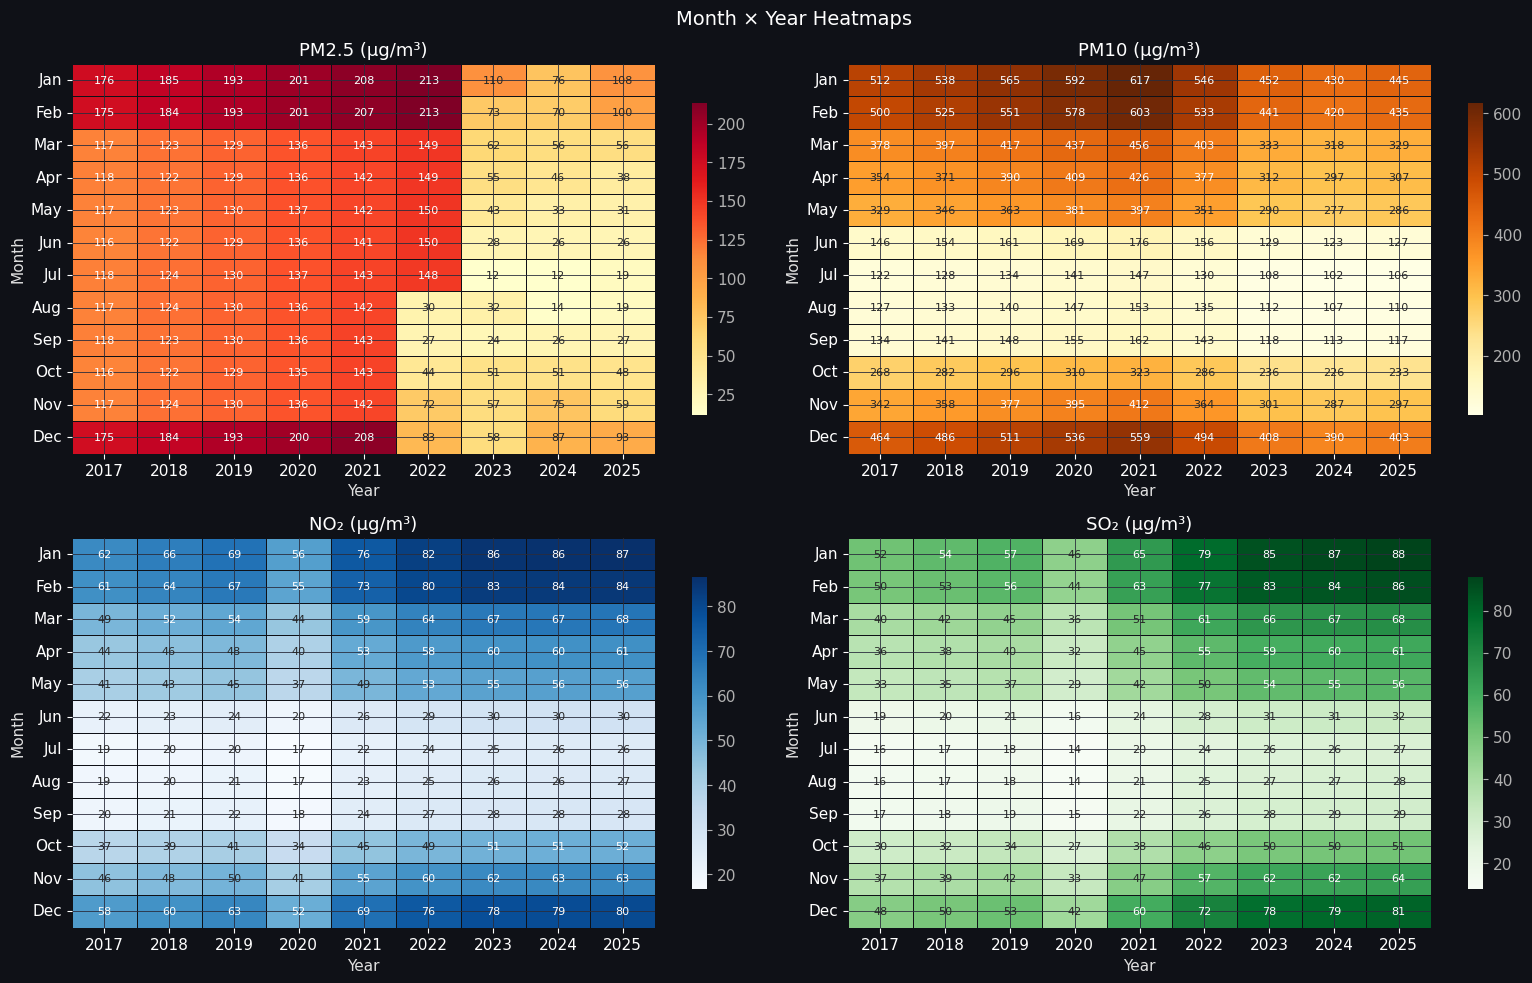

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Month × Year Heatmaps', fontsize=14, color='white')

for ax, (col, label, cmap) in zip(axes.flat, [
    ('pm25_mean', 'PM2.5 (µg/m³)', 'YlOrRd'),
    ('pm10_mean', 'PM10 (µg/m³)',  'YlOrBr'),
    ('no2_mean',  'NO₂ (µg/m³)',   'Blues'),
    ('so2_mean',  'SO₂ (µg/m³)',   'Greens'),
]):
    pivot = df.pivot_table(index='month', columns='year', values=col, aggfunc='mean')
    pivot.index = month_labels
    sns.heatmap(pivot, ax=ax, cmap=cmap, annot=True, fmt='.0f',
                annot_kws={'size': 8}, linewidths=0.4, linecolor='#0f1117',
                cbar_kws={'shrink': 0.8})
    ax.set_title(label, color='white')
    ax.set_xlabel('Year')
    ax.set_ylabel('Month')
    ax.tick_params(colors='white')

plt.tight_layout()
plt.show()

## 10. Rolling Statistics & Trend Decomposition

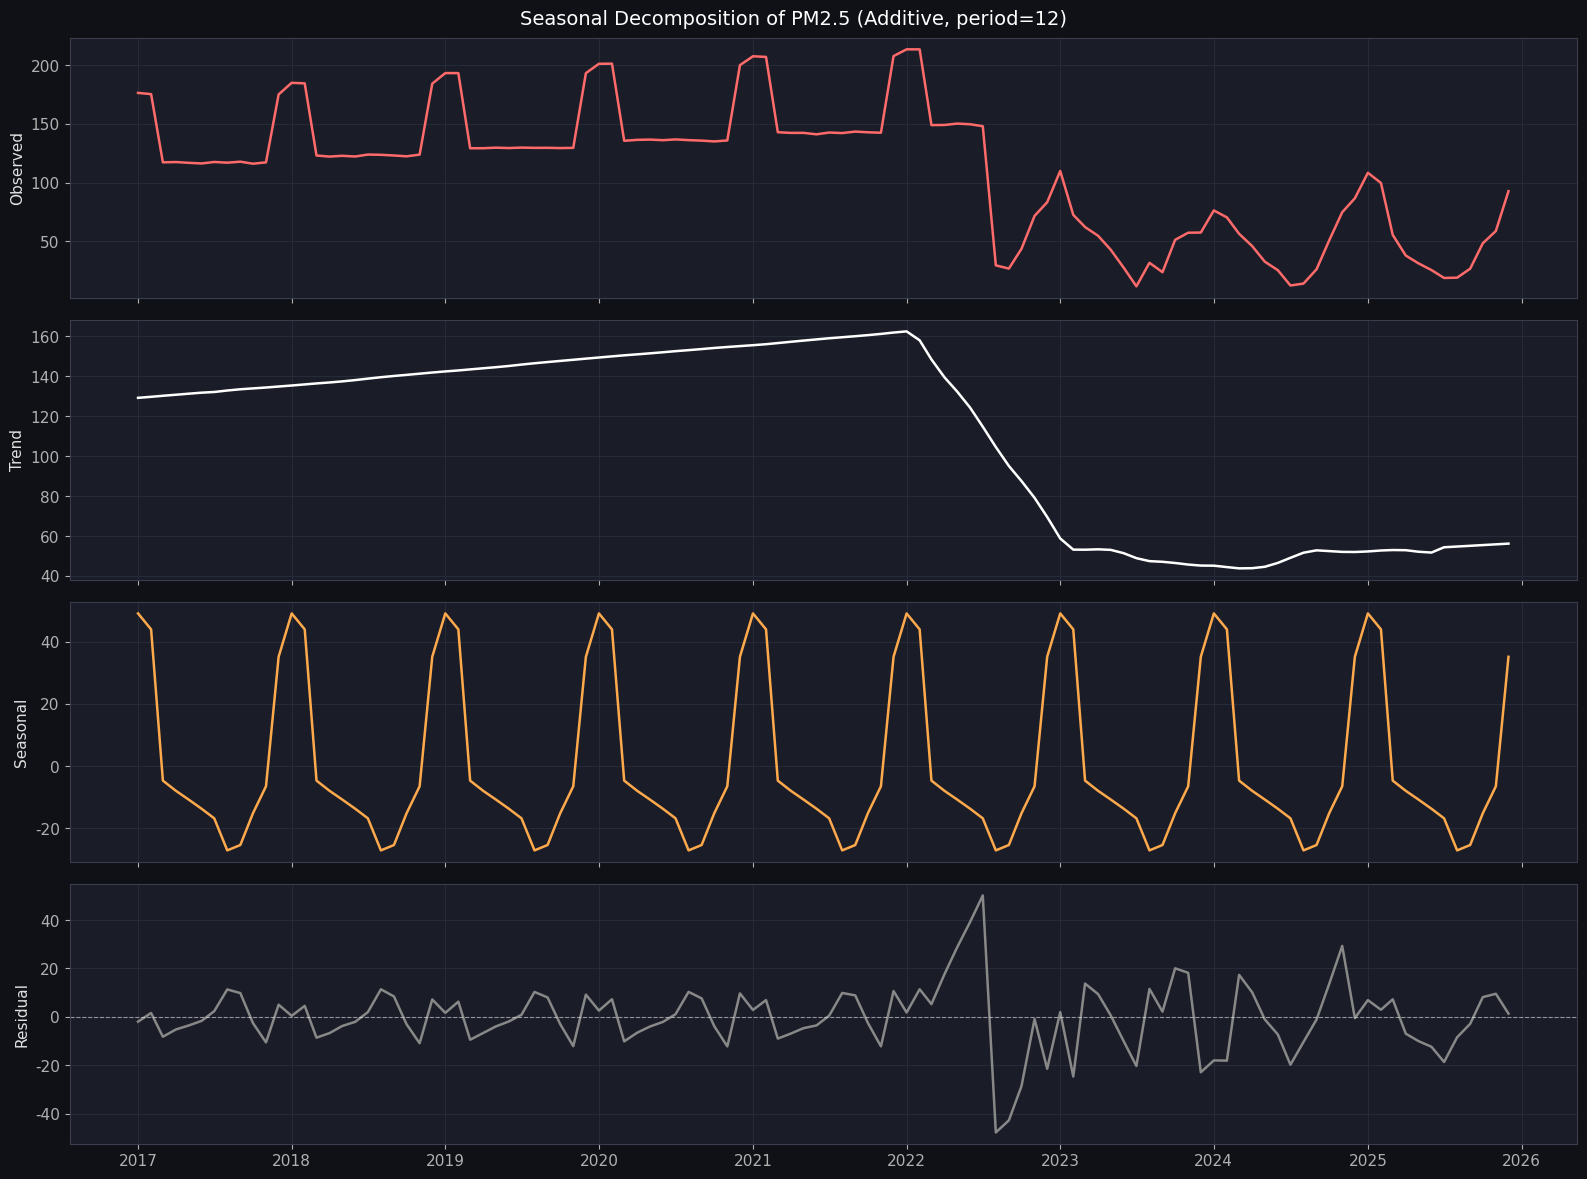

In [19]:
# Seasonal decomposition of PM2.5
pm25_series = df.set_index('month_start')['pm25_mean']
decomp = seasonal_decompose(pm25_series, model='additive', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Seasonal Decomposition of PM2.5 (Additive, period=12)', fontsize=14, color='white')

components = [
    (pm25_series,     'Observed',  PAL['pm25']),
    (decomp.trend,    'Trend',     '#ffffff'),
    (decomp.seasonal, 'Seasonal',  '#FFA94D'),
    (decomp.resid,    'Residual',  '#888'),
]
for ax, (data, label, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, lw=1.8)
    if label == 'Residual':
        ax.axhline(0, color='white', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_ylabel(label)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

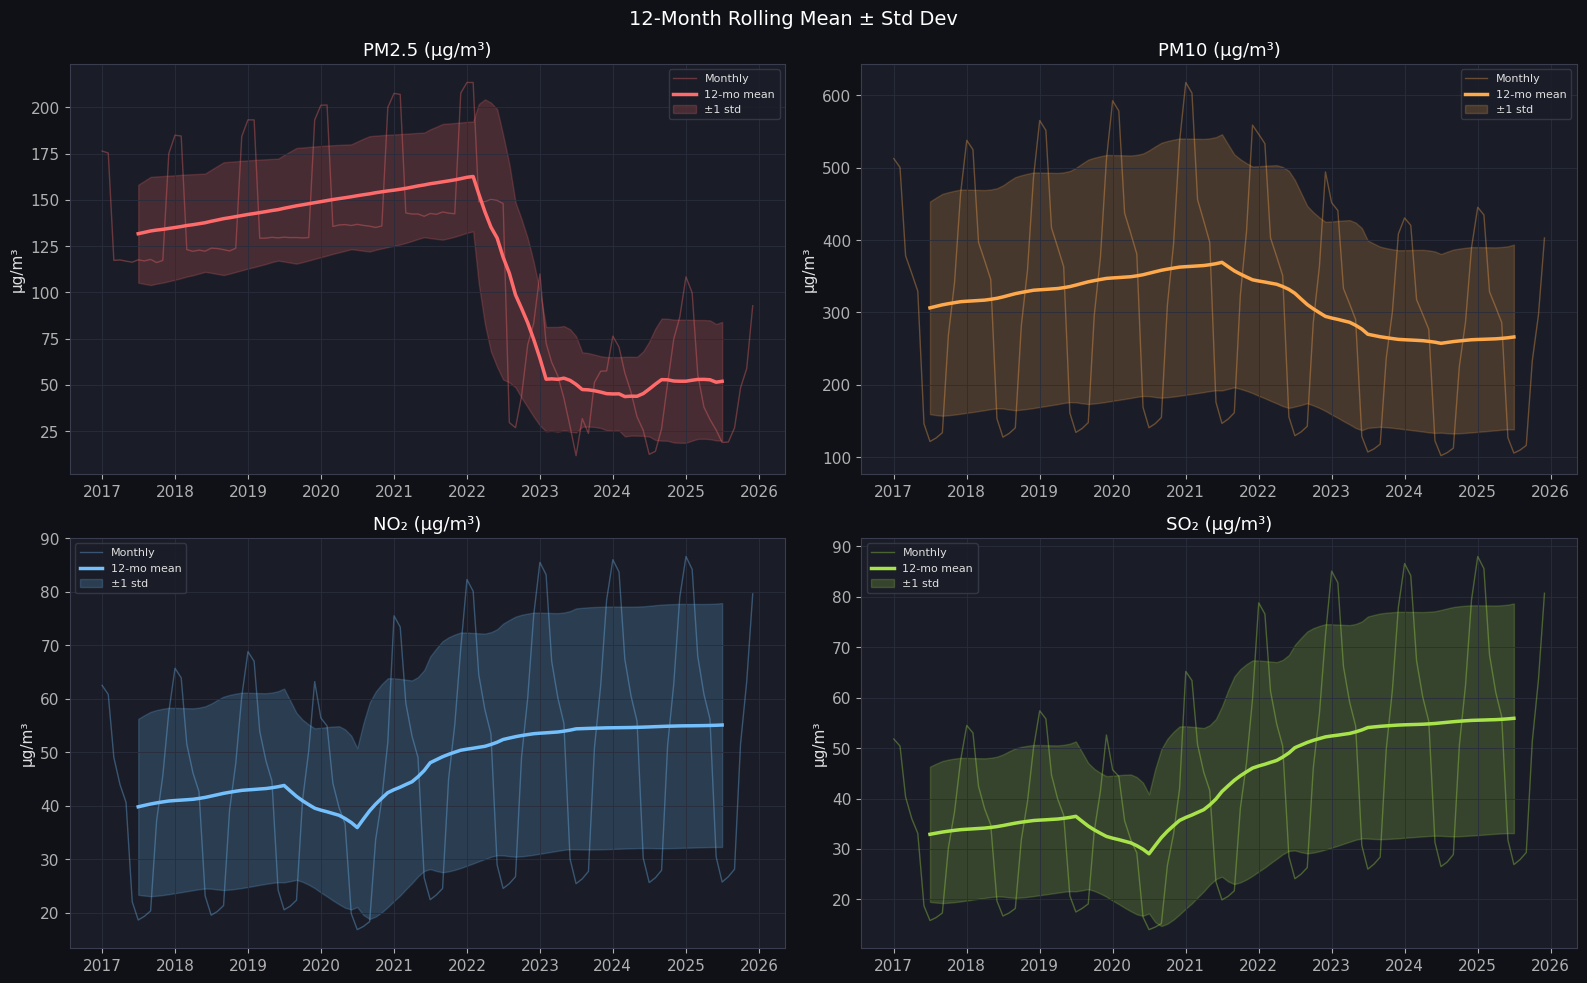

In [20]:
# Rolling mean & std for all 4 pollutants
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('12-Month Rolling Mean ± Std Dev', fontsize=14, color='white')

for ax, (col, label, color) in zip(axes.flat, [
    ('pm25_mean', 'PM2.5', PAL['pm25']),
    ('pm10_mean', 'PM10',  PAL['pm10']),
    ('no2_mean',  'NO₂',   PAL['no2']),
    ('so2_mean',  'SO₂',   PAL['so2']),
]):
    s = df.set_index('month_start')[col]
    roll_mean = s.rolling(12, center=True).mean()
    roll_std  = s.rolling(12, center=True).std()
    ax.plot(s.index, s.values, color=color, alpha=0.35, lw=1, label='Monthly')
    ax.plot(roll_mean.index, roll_mean.values, color=color, lw=2.5, label='12-mo mean')
    ax.fill_between(roll_mean.index,
                    roll_mean - roll_std, roll_mean + roll_std,
                    alpha=0.2, color=color, label='±1 std')
    ax.set_title(f'{label} (µg/m³)')
    ax.set_ylabel('µg/m³')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## 11. Correlation Analysis

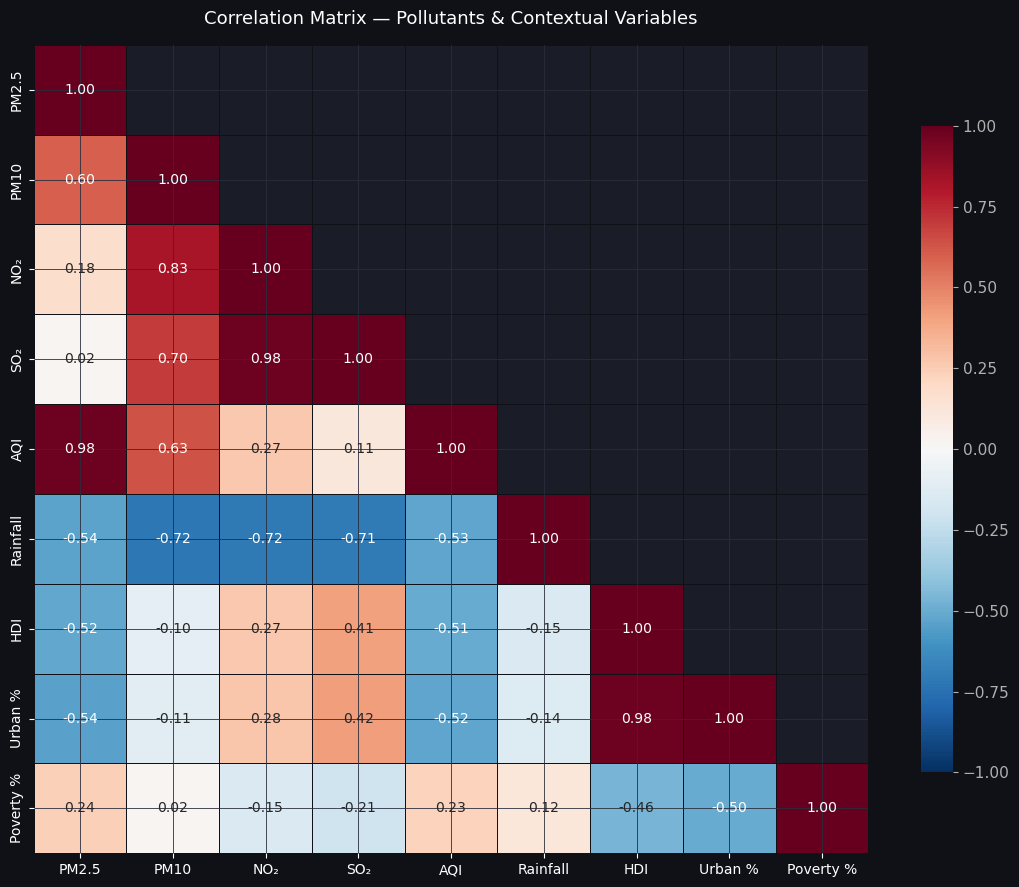

In [21]:
corr_cols = ['pm25_mean','pm10_mean','no2_mean','so2_mean','aqi_mean',
             'norm_rain','hdi','urban_share_pct','poverty_rate_pct']
corr_labels = ['PM2.5','PM10','NO₂','SO₂','AQI','Rainfall','HDI','Urban %','Poverty %']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, ax=ax,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    xticklabels=corr_labels, yticklabels=corr_labels,
    linewidths=0.5, linecolor='#0f1117',
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix — Pollutants & Contextual Variables', color='white', fontsize=13, pad=15)
ax.tick_params(colors='white', labelsize=10)
plt.tight_layout()
plt.show()

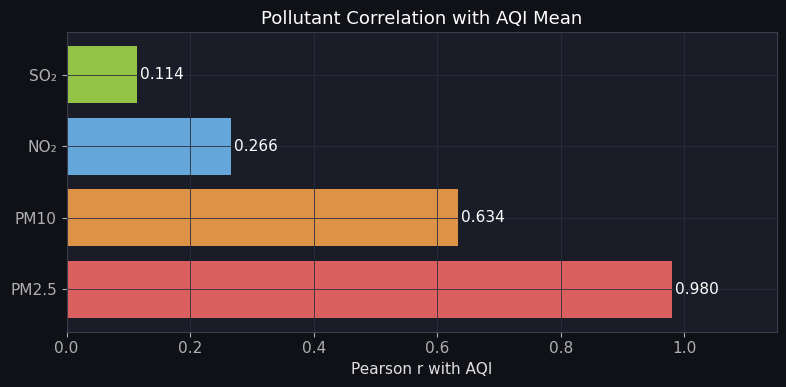

In [22]:
# Correlation between pollutant means and AQI — bar chart
corr_with_aqi = df[['pm25_mean','pm10_mean','no2_mean','so2_mean']].corrwith(df['aqi_mean'])
corr_with_aqi.index = ['PM2.5','PM10','NO₂','SO₂']

fig, ax = plt.subplots(figsize=(8, 4))
bar_cols = [PAL['pm25'], PAL['pm10'], PAL['no2'], PAL['so2']]
bars = ax.barh(corr_with_aqi.index, corr_with_aqi.values, color=bar_cols, alpha=0.85)
for bar, val in zip(bars, corr_with_aqi.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, color='white')
ax.axvline(0, color='white', lw=0.8, alpha=0.4)
ax.set_xlim(0, 1.15)
ax.set_xlabel('Pearson r with AQI')
ax.set_title('Pollutant Correlation with AQI Mean')
plt.tight_layout()
plt.show()

## 12. Key Insights Summary

In [23]:
# ── Compute headline stats ─────────────────────────────────────────────────
who_exceedance = {}
for pol, who_val in WHO.items():
    col = f'{pol}_mean'
    pct = (df[col] > who_val).mean() * 100
    ratio = df[col].mean() / who_val
    who_exceedance[pol] = (pct, ratio)

worst_month = df.loc[df['aqi_mean'].idxmax()]
best_month  = df.loc[df['aqi_mean'].idxmin()]

lockdown_pm25_change = (
    (lockdown['pm25_mean'].mean() - pre_covid['pm25_mean'].mean())
    / pre_covid['pm25_mean'].mean() * 100
)

rain_corr_pm25 = rain_df[['norm_rain','pm25_mean']].corr().iloc[0,1]

print('=' * 62)
print('   DHAKA AIR QUALITY — KEY INSIGHTS (2017–2025)')
print('=' * 62)
print()
print('📊 WHO GUIDELINE EXCEEDANCE')
for pol, (pct, ratio) in who_exceedance.items():
    print(f'   {pol.upper():5s}  {pct:5.1f}% of months exceeded WHO limit  ({ratio:.1f}× guideline on avg)')
print()
print('📅 EXTREMES')
print(f'   Worst month : {worst_month.month_start.strftime("%b %Y")}  (AQI = {worst_month.aqi_mean:.1f}, {worst_month.season})')
print(f'   Best month  : {best_month.month_start.strftime("%b %Y")}   (AQI = {best_month.aqi_mean:.1f}, {best_month.season})')
print()
print('🦠 COVID-19 LOCKDOWN IMPACT')
print(f'   PM2.5 changed {lockdown_pm25_change:+.1f}% during lockdown vs pre-COVID mean')
print()
print('🌧️  RAINFALL RELATIONSHIP')
print(f'   Pearson r (rainfall vs PM2.5) = {rain_corr_pm25:.2f}  — {'strong' if abs(rain_corr_pm25)>0.5 else 'moderate'} negative correlation')
print()
print('🌡️  SEASONALITY')
season_aqi = df.groupby('season')['aqi_mean'].mean().sort_values(ascending=False)
for s, v in season_aqi.items():
    print(f'   {s:<15s} mean AQI = {v:.1f}')
print()
print('📈 NO₂ & SO₂ TREND (2017 → 2025)')
no2_start = df[df['year']==2017]['no2_mean'].mean()
no2_end   = df[df['year']==2025]['no2_mean'].mean()
so2_start = df[df['year']==2017]['so2_mean'].mean()
so2_end   = df[df['year']==2025]['so2_mean'].mean()
print(f'   NO₂  {no2_start:.1f} → {no2_end:.1f} µg/m³  ({(no2_end-no2_start)/no2_start*100:+.1f}%)')
print(f'   SO₂  {so2_start:.1f} → {so2_end:.1f} µg/m³  ({(so2_end-so2_start)/so2_start*100:+.1f}%)')
print('=' * 62)

   DHAKA AIR QUALITY — KEY INSIGHTS (2017–2025)

📊 WHO GUIDELINE EXCEEDANCE
   PM25    97.2% of months exceeded WHO limit  (7.4× guideline on avg)
   PM10   100.0% of months exceeded WHO limit  (6.9× guideline on avg)
   NO2    100.0% of months exceeded WHO limit  (4.7× guideline on avg)
   SO2     50.9% of months exceeded WHO limit  (1.1× guideline on avg)

📅 EXTREMES
   Worst month : Jan 2022  (AQI = 263.2, Winter)
   Best month  : Jul 2023   (AQI = 44.5, Monsoon)

🦠 COVID-19 LOCKDOWN IMPACT
   PM2.5 changed -3.9% during lockdown vs pre-COVID mean

🌧️  RAINFALL RELATIONSHIP
   Pearson r (rainfall vs PM2.5) = -0.54  — strong negative correlation

🌡️  SEASONALITY
   Winter          mean AQI = 215.3
   Pre-monsoon     mean AQI = 170.6
   Post-monsoon    mean AQI = 165.8
   Monsoon         mean AQI = 145.7

📈 NO₂ & SO₂ TREND (2017 → 2025)
   NO₂  39.8 → 55.1 µg/m³  (+38.5%)
   SO₂  32.9 → 55.9 µg/m³  (+69.9%)


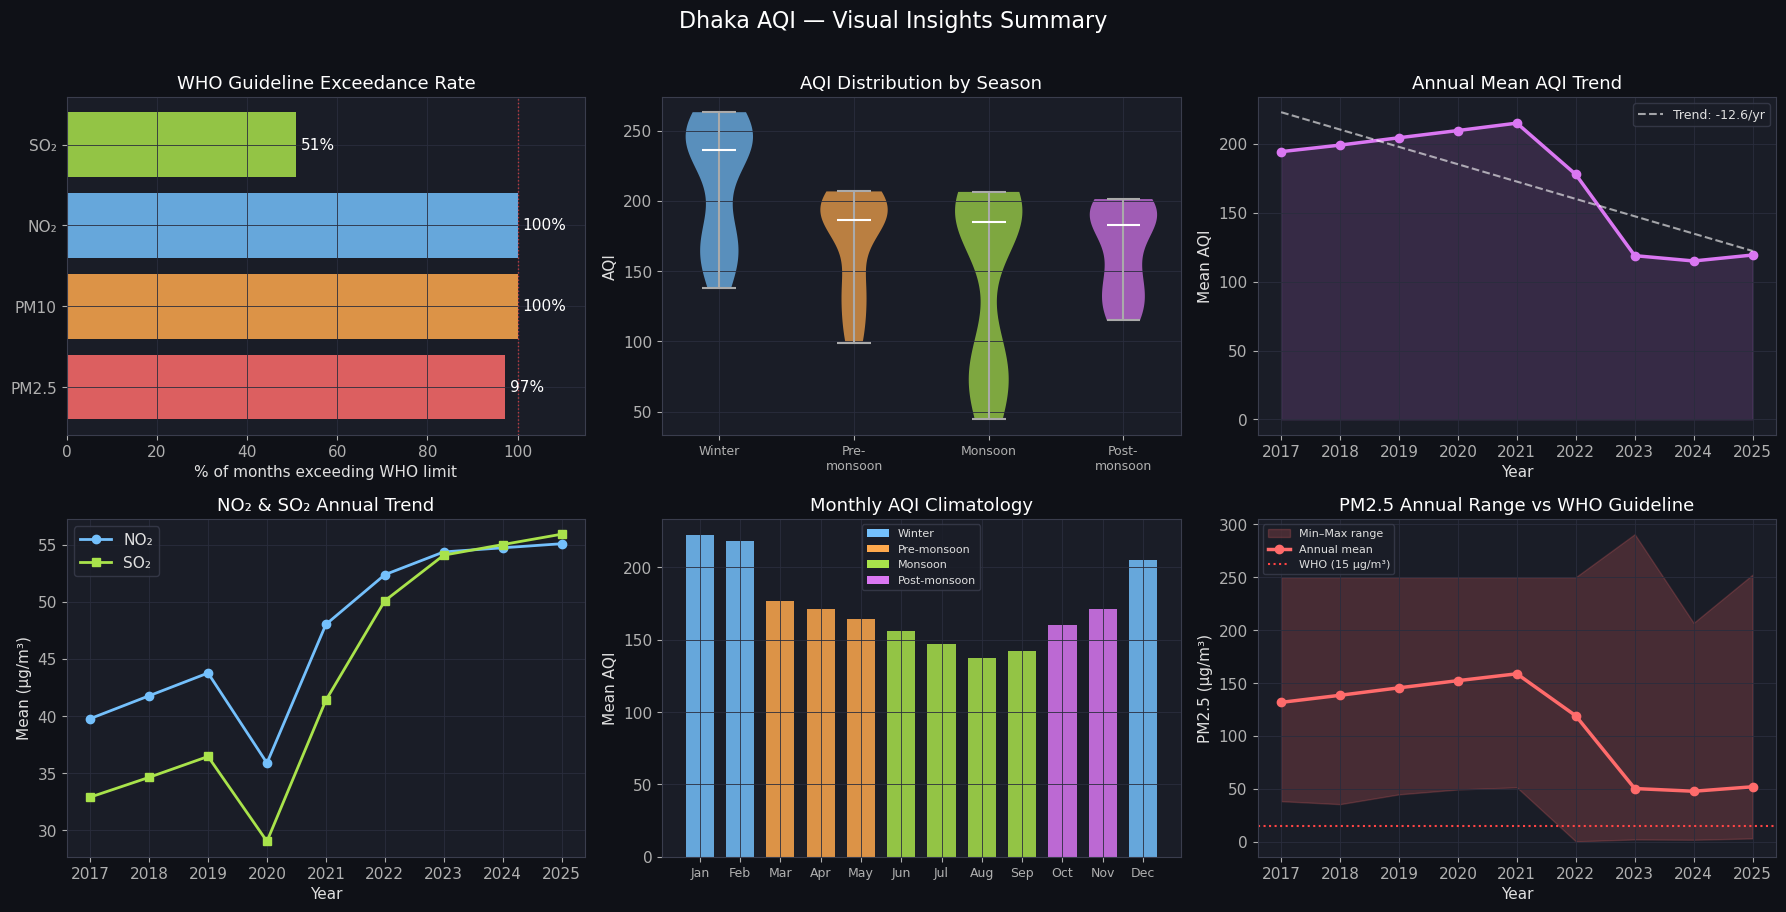


✅ Analysis complete.


In [24]:
# Visual summary card
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Dhaka AQI — Visual Insights Summary', fontsize=16, color='white', y=1.01)

# 1. WHO exceedance donut charts
for ax, (pol, color) in zip(axes[0][:4], [
    ('pm25', PAL['pm25']), ('pm10', PAL['pm10']),
    ('no2',  PAL['no2']),  ('so2',  PAL['so2'])
]):
    pass  # handled below

# ── Panel 1: WHO exceedance by pollutant ──
ax = axes[0][0]
pols = ['pm25','pm10','no2','so2']
pcts = [who_exceedance[p][0] for p in pols]
col_list = [PAL[p] for p in pols]
bars = ax.barh(['PM2.5','PM10','NO₂','SO₂'], pcts, color=col_list, alpha=0.85)
for bar, pct in zip(bars, pcts):
    ax.text(pct+1, bar.get_y()+bar.get_height()/2, f'{pct:.0f}%', va='center', fontsize=11, color='white')
ax.axvline(100, color='#FF4444', lw=1, linestyle=':', alpha=0.7)
ax.set_xlim(0, 115)
ax.set_xlabel('% of months exceeding WHO limit')
ax.set_title('WHO Guideline Exceedance Rate')

# ── Panel 2: AQI by season violin ──
ax = axes[0][1]
season_data = [df[df['season']==s]['aqi_mean'].values for s in season_order]
parts = ax.violinplot(season_data, positions=range(4), showmedians=True, showextrema=True)
for i, (pc, s) in enumerate(zip(parts['bodies'], season_order)):
    pc.set_facecolor(SEASON_PAL[s])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('white')
parts['cmins'].set_color('#aaa')
parts['cmaxes'].set_color('#aaa')
parts['cbars'].set_color('#aaa')
ax.set_xticks(range(4))
ax.set_xticklabels(['Winter','Pre-\nmonsoon','Monsoon','Post-\nmonsoon'], fontsize=9)
ax.set_ylabel('AQI')
ax.set_title('AQI Distribution by Season')

# ── Panel 3: Annual AQI trend ──
ax = axes[0][2]
ann = df.groupby('year')['aqi_mean'].mean()
ax.plot(ann.index, ann.values, marker='o', color=PAL['aqi'], lw=2.5)
ax.fill_between(ann.index, ann.values, alpha=0.15, color=PAL['aqi'])
slope, intercept, *_ = stats.linregress(ann.index, ann.values)
ax.plot(ann.index, slope*ann.index+intercept, color='white', lw=1.5, linestyle='--', alpha=0.6, label=f'Trend: {slope:+.1f}/yr')
ax.set_title('Annual Mean AQI Trend')
ax.set_ylabel('Mean AQI')
ax.set_xlabel('Year')
ax.legend(fontsize=9)
ax.set_xticks(ann.index)

# ── Panel 4: NO₂ & SO₂ annual trend ──
ax = axes[1][0]
no2_ann = df.groupby('year')['no2_mean'].mean()
so2_ann = df.groupby('year')['so2_mean'].mean()
ax.plot(no2_ann.index, no2_ann.values, marker='o', color=PAL['no2'], lw=2, label='NO₂')
ax.plot(so2_ann.index, so2_ann.values, marker='s', color=PAL['so2'], lw=2, label='SO₂')
ax.set_title('NO₂ & SO₂ Annual Trend')
ax.set_ylabel('Mean (µg/m³)')
ax.set_xlabel('Year')
ax.legend()
ax.set_xticks(no2_ann.index)

# ── Panel 5: Monthly climatology of AQI ──
ax = axes[1][1]
clim = df.groupby('month')['aqi_mean'].mean()
bar_colors = [SEASON_PAL[s] for s in
    ['Winter','Winter','Pre-monsoon','Pre-monsoon','Pre-monsoon',
     'Monsoon','Monsoon','Monsoon','Monsoon','Post-monsoon','Post-monsoon','Winter']]
ax.bar(clim.index, clim.values, color=bar_colors, alpha=0.85, width=0.7)
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels, fontsize=9)
ax.set_ylabel('Mean AQI')
ax.set_title('Monthly AQI Climatology')
legend_els = [Patch(facecolor=c, label=s) for s, c in SEASON_PAL.items()]
ax.legend(handles=legend_els, fontsize=8)

# ── Panel 6: PM2.5 min/mean/max range by year ──
ax = axes[1][2]
pm_yr = df.groupby('year').agg(mean=('pm25_mean','mean'), lo=('pm25_min','min'), hi=('pm25_max','max'))
ax.fill_between(pm_yr.index, pm_yr['lo'], pm_yr['hi'], alpha=0.2, color=PAL['pm25'], label='Min–Max range')
ax.plot(pm_yr.index, pm_yr['mean'], marker='o', color=PAL['pm25'], lw=2.5, label='Annual mean')
ax.axhline(WHO['pm25'], color='#FF4444', lw=1.5, linestyle=':', label=f'WHO ({WHO["pm25"]} µg/m³)')
ax.set_title('PM2.5 Annual Range vs WHO Guideline')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_xlabel('Year')
ax.legend(fontsize=8)
ax.set_xticks(pm_yr.index)

plt.tight_layout()
plt.show()

print('\n✅ Analysis complete.')